In [1]:
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau

import os, gc, glob, json
from pathlib import Path

# Load CSV data file

In [2]:
final_df = pd.read_csv("data/disruption_analysis.csv")

In [3]:
final_df = final_df[final_df.doctype == "article"]

final_df = final_df[final_df["team_size"] <= 40]
final_df = final_df[final_df["year"] >= 1971]

final_df = final_df[
    ~((final_df["first_time_author_ratio"] == 1) & (final_df["avg_career_age"] > 0))
]
final_df = final_df[
    ~(
        (final_df["first_time_author_ratio"] == 1)
        & (final_df["senior_author_avg_disruption"] > 0)
    )
]
final_df = final_df[
    ~(
        (final_df["first_time_author_ratio"] == 1)
        & (final_df["mid_career_author_ratio"] > 0)
    )
]
final_df = final_df[
    ~(
        (final_df["first_time_author_ratio"] == 1)
        & (final_df["early_author_avg_disruption"] > 0)
    )
]

final_df["year"] = final_df["year"].astype(int)

final_df["decade_start"] = ((final_df["year"] - 1) // 10) * 10 + 1
final_df["decade_end"] = final_df["decade_start"] + 9
final_df["decade"] = (
    final_df["decade_start"].astype(str) + "-" + final_df["decade_end"].astype(str)
)

# We want to merge mid_career_author_ratio with early_career_author_ratio and delete mid_career_author_ratio
final_df["early_career_author_ratio"] = (
    final_df["early_career_author_ratio"] + final_df["mid_career_author_ratio"]
)

# Handle null values in disruption calculations
final_df["early_author_avg_disruption"] = np.where(
    final_df["early_author_avg_disruption"].isna()
    | final_df["mid_author_avg_disruption"].isna(),
    np.nan,
    (final_df["early_author_avg_disruption"] + final_df["mid_author_avg_disruption"])
    / 2,
)

final_df.drop(
    columns=[
        "decade_start",
        "decade_end",
        "mid_career_author_ratio",
        "mid_author_avg_disruption",
    ],
    inplace=True,
)

final_df["disruption_percentile"] = final_df["disruption"].rank(pct=True) * 100

final_df["citation_count_percentile"] = final_df["citation_count"].rank(pct=True) * 100
final_df["C10_percentile"] = final_df["C10"].rank(pct=True) * 100


final_df["avg_disruption_percentile"] = final_df["avg_disruption"].rank(pct=True) * 100
final_df["avg_citation_count_percentile"] = (
    final_df["avg_citation_count"].rank(pct=True) * 100
)

final_df["Atyp_Median_Z_percentile"] = final_df["Atyp_Median_Z"].rank(pct=True) * 100
final_df["avg_reference_age_percentile"] = (
    final_df["avg_reference_age"].rank(pct=True) * 100
)
final_df["median_reference_age_percentile"] = (
    final_df["median_reference_age"].rank(pct=True) * 100
)
final_df["avg_reference_popularity_percentile"] = (
    final_df["avg_reference_popularity"].rank(pct=True) * 100
)
final_df["median_reference_popularity_percentile"] = (
    final_df["median_reference_popularity"].rank(pct=True) * 100
)

gc.collect()

0

In [4]:
def avg_disruption_group(x):
    if pd.isna(x):  # Handle null values
        return None
    if x < 60:
        return "0-60 percentile"
    elif x < 70:
        return "60-70 percentile"
    elif x < 80:
        return "70-80 percentile"
    elif x < 90:
        return "80-90 percentile"
    else:
        return "90-100 percentile"


final_df["co_authors_disruption_group"] = final_df["avg_disruption_percentile"].apply(
    avg_disruption_group
)
final_df["co_authors_citation_group"] = final_df["avg_citation_count_percentile"].apply(
    avg_disruption_group
)

# Get the avg_disruption values sorted to use as reference scale
avg_disruption_sorted = final_df["avg_disruption"].sort_values().values


# Function to find percentile of a value in the reference distribution
def find_percentile_in_reference(value, reference_array):
    if pd.isna(value):
        return np.nan
    # Find where this value would rank in the reference array
    percentile = (
        np.searchsorted(reference_array, value, side="right")
        / len(reference_array)
        * 100
    )
    return percentile


# Apply to Senior and Early Career Author Disruption - keeping null if original values are null
final_df["senior_author_disruption_percentile"] = np.where(
    final_df["senior_author_avg_disruption"].isna(),
    np.nan,
    final_df["senior_author_avg_disruption"].apply(
        lambda x: find_percentile_in_reference(x, avg_disruption_sorted)
    ),
)

final_df["early_career_disruption_percentile"] = np.where(
    final_df["early_author_avg_disruption"].isna(),
    np.nan,
    final_df["early_author_avg_disruption"].apply(
        lambda x: find_percentile_in_reference(x, avg_disruption_sorted)
    ),
)

# Now apply the bucketing function - this will handle nulls properly
final_df["senior_author_disruption_bucket"] = final_df[
    "senior_author_disruption_percentile"
].apply(avg_disruption_group)
final_df["early_career_disruption_bucket"] = final_df[
    "early_career_disruption_percentile"
].apply(avg_disruption_group)

gc.collect()

0

In [5]:
print(final_df.shape)
gc.collect()

(28042889, 63)


0

In [6]:
def setup_plotting_style():
    plt.figure(figsize=(8, 6), dpi=300)

    sns.set_style("white")

    plt.rcParams["font.size"] = 12
    plt.rcParams["axes.labelsize"] = 14
    plt.rcParams["axes.titlesize"] = 16
    plt.rcParams["xtick.labelsize"] = 12
    plt.rcParams["ytick.labelsize"] = 12
    plt.rcParams["legend.fontsize"] = 12
    plt.rcParams["figure.titlesize"] = 18

    plt.rcParams["axes.linewidth"] = 1.5
    plt.rcParams["grid.linewidth"] = 0.8
    plt.rcParams["lines.linewidth"] = 2.0

    sns.set_palette("colorblind")

    # Save format settings
    plt.rcParams["savefig.format"] = "pdf"
    plt.rcParams["savefig.bbox"] = "tight"
    plt.rcParams["savefig.pad_inches"] = 0.1


setup_plotting_style()

<Figure size 2400x1800 with 0 Axes>

In [7]:
!mkdir Figures

mkdir: Figures: File exists


# Early-career and disruptive collaborators are linked to greater disruption in beginner-heavy teams

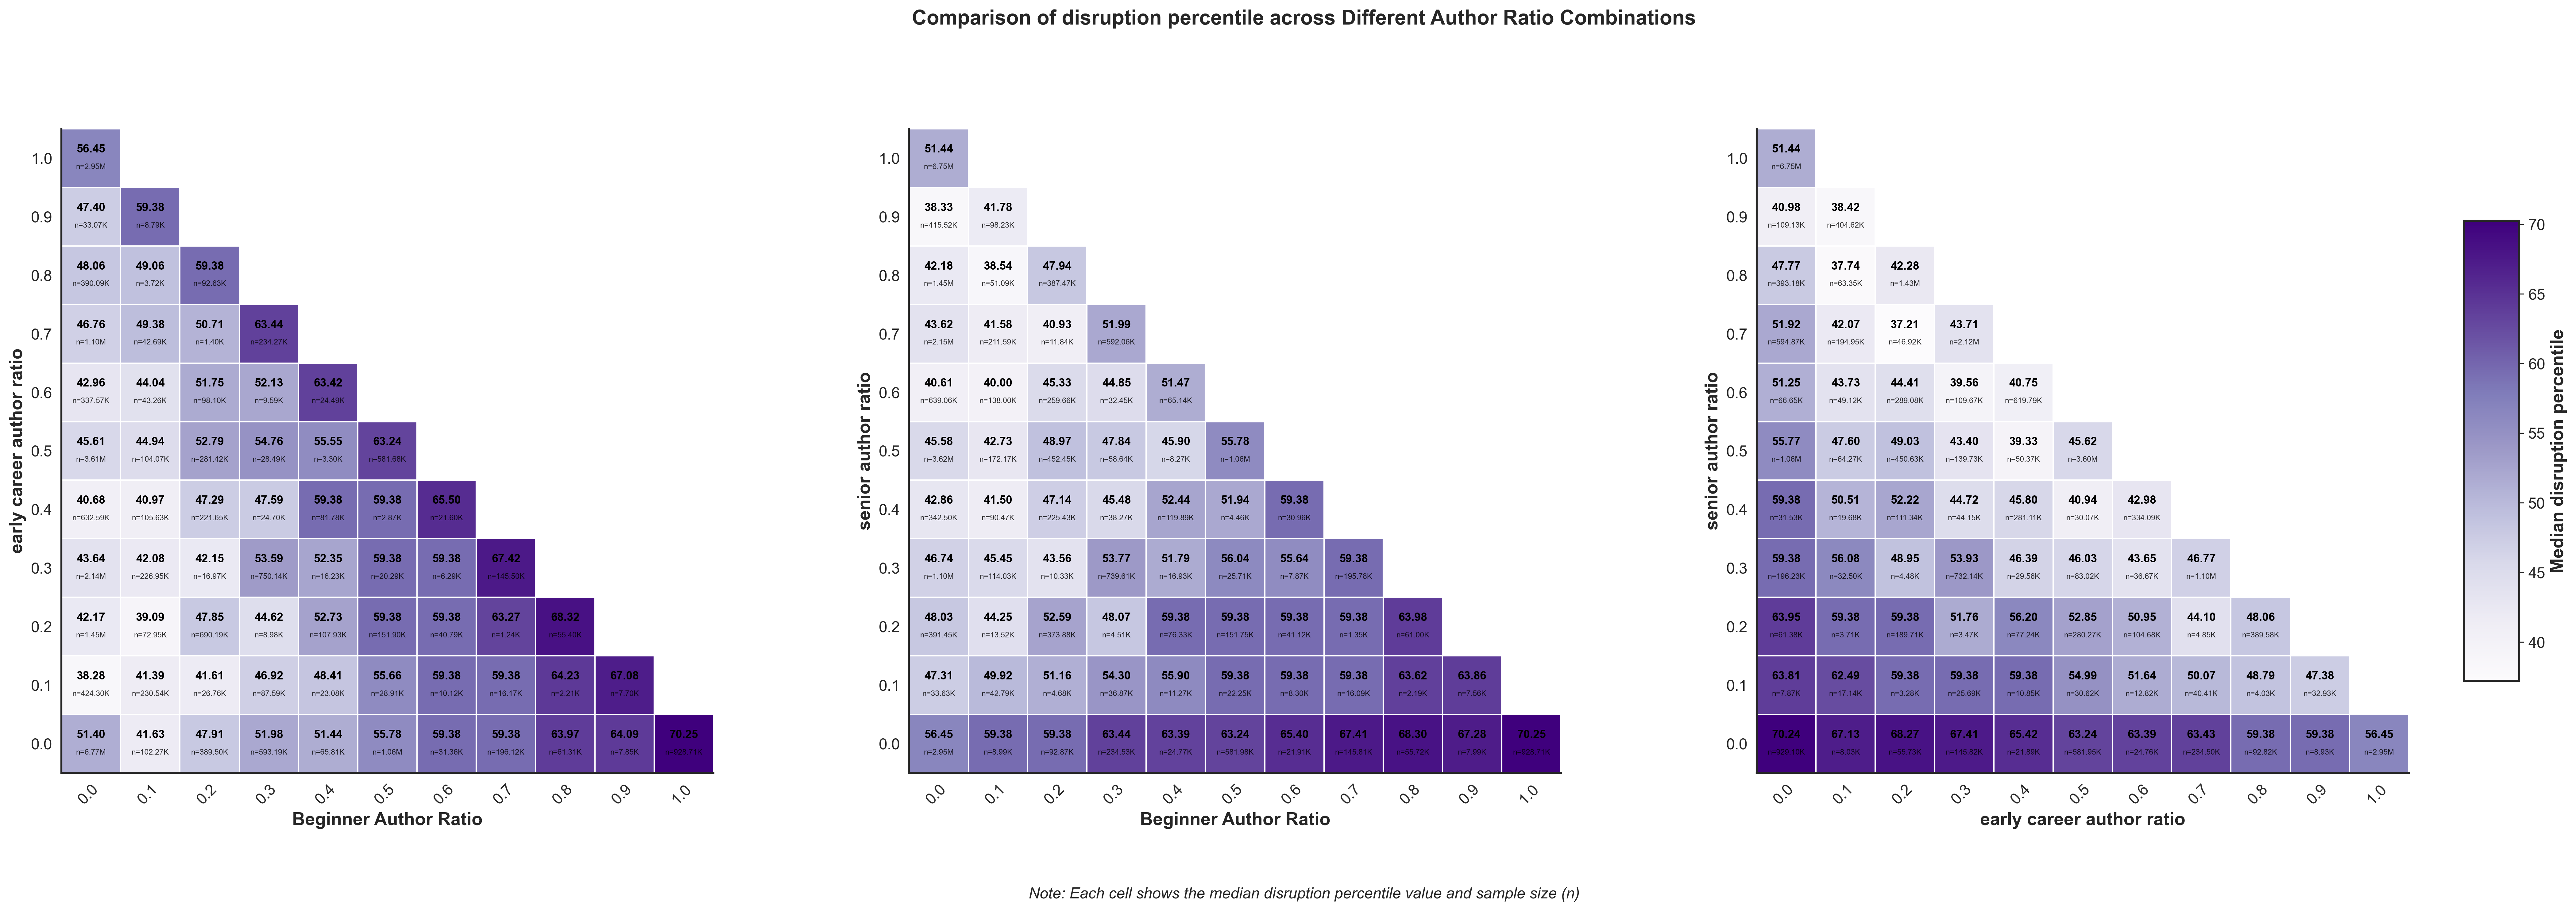

In [26]:
def plot_expanded_disruption_heatmaps(
    df,
    target_column="disruption_percentile",
    main_columns=[
        "first_time_author_ratio",
        "early_career_author_ratio",
        "senior_author_ratio",
    ],
    x_bins=11,
    y_bins=11,
    method="median",
    min_group_size=10,
    cmap="Reds",
    annotate=True,
    save_path=None,
):
    """
    Create a figure with three subplots showing disruption values for different combinations of author ratios.
    Single row: First-time authors vs career stages, and career stages compared against each other

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the data
    target_column : str, default="disruption_percentile"
        The column containing the target values to aggregate
    main_columns : list, default=["first_time_author_ratio", "early_career_author_ratio", "senior_author_ratio"]
        The columns to use for the different axes. Order matters:
        - main_columns[0] is typically first_time_author_ratio (x-axis for first two plots)
        - main_columns[1:3] are the different career stages
    x_bins : int, default=11
        Number of bins for the x-axis
    y_bins : int, default=11
        Number of bins for the y-axis
    method : str, default="mean" or "median"
        Aggregation method, either "mean" or "median"
    min_group_size : int, default=10
        Minimum number of observations required in each bin
    cmap : str, default="Reds"
        Colormap to use for the heatmap
    annotate : bool, default=True
        Whether to annotate the heatmap cells with values and counts
    save_path : str or None, default=None
        If provided, the figure will be saved to this path

    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object containing all three subplots
    axes : list of matplotlib.axes.Axes
        The list of axes objects for each subplot
    pivot_dfs : list of pandas.DataFrame
        The list of pivoted dataframes used for each heatmap
    """
    from matplotlib.colors import Normalize

    if method not in ["mean", "median"]:
        raise ValueError("Method must be either 'mean' or 'median'")

    # Close any existing figures
    plt.close("all")

    # Create figure and subplots (1 row, 3 columns)
    fig, axes = plt.subplots(1, 3, figsize=(30, 10), dpi=300)

    # Extract columns for easier reference
    fresh_ratio = main_columns[0]
    career_stages = main_columns[1:3]

    # Define all axis pairs we want to plot (3 combinations)
    plot_configs = [
        # first_time_author_ratio (x-axis) vs each career stage (y-axis)
        {"x_column": fresh_ratio, "y_column": career_stages[0]},  # Fresh vs Early
        {"x_column": fresh_ratio, "y_column": career_stages[1]},  # Fresh vs Senior
        # Career stages compared to each other
        {"x_column": career_stages[0], "y_column": career_stages[1]},  # Early vs Senior
    ]

    # Lists to store results
    pivot_dfs = []
    all_values = []

    # Process each subplot configuration
    for config in plot_configs:
        x_column = config["x_column"]
        y_column = config["y_column"]

        # Create a copy with only the necessary columns
        df_subset = df[[x_column, y_column, target_column]].copy()

        # Create equally spaced bins between 0 and 1 for both author ratios
        x_bin_edges = np.linspace(0, 1, x_bins + 1)
        y_bin_edges = np.linspace(0, 1, y_bins + 1)

        # Create bin categories with labels
        df_subset["x_bin"] = pd.cut(
            df_subset[x_column], bins=x_bin_edges, include_lowest=True
        )
        df_subset["y_bin"] = pd.cut(
            df_subset[y_column], bins=y_bin_edges, include_lowest=True
        )

        # Drop original ratio columns as they're no longer needed
        df_subset.drop([x_column, y_column], axis=1, inplace=True)
        gc.collect()

        # Group by bins and compute the aggregated value and count
        grouped = (
            df_subset.groupby(["y_bin", "x_bin"], observed=False)
            .agg({target_column: [method, "count"]})
            .reset_index()
        )

        # Clean up the subset dataframe
        del df_subset
        gc.collect()

        # Rename columns for clarity
        grouped.columns = ["y_bin", "x_bin", "value", "count"]

        # Filter by minimum group size
        grouped = grouped[grouped["count"] >= min_group_size]

        # Create pivot table for heatmap
        pivot_df = grouped.pivot_table(
            index="y_bin", columns="x_bin", values="value", observed=False
        )

        # Create counts pivot table for reference
        counts_df = grouped.pivot_table(
            index="y_bin", columns="x_bin", values="count", observed=False
        )

        # Store the pivot df and counts
        pivot_dfs.append({"pivot": pivot_df, "counts": counts_df})

        # Collect all non-NaN values for consistent color scaling
        all_values.extend(pivot_df.values[~np.isnan(pivot_df.values)])

        # Free memory from grouped dataframe
        del grouped
        gc.collect()

    # Create a common color scale
    vmin, vmax = min(all_values), max(all_values)
    norm = Normalize(vmin=vmin, vmax=vmax)

    # Process each subplot
    for i, (config, pivot_data) in enumerate(zip(plot_configs, pivot_dfs)):
        ax = axes[i]
        pivot_df = pivot_data["pivot"]
        counts_df = pivot_data["counts"]

        x_column = config["x_column"]
        y_column = config["y_column"]

        # Get bin centers for tick labels
        x_centers = [b.mid for b in pivot_df.columns]
        y_centers = [b.mid for b in pivot_df.index]

        # Format tick labels
        x_labels = [f"{c:.1f}" for c in x_centers]
        y_labels = [f"{c:.1f}" for c in y_centers]

        # Create the heatmap with masked data
        masked_data = np.ma.masked_invalid(pivot_df.values)
        im = ax.imshow(
            masked_data,
            cmap=cmap,
            aspect="auto",
            origin="lower",
            interpolation="nearest",
            norm=norm,  # Apply the common normalization
        )

        # Set tick positions and labels
        ax.set_xticks(np.arange(len(x_centers)))
        ax.set_yticks(np.arange(len(y_centers)))
        ax.set_xticklabels(x_labels)
        ax.set_yticklabels(y_labels)

        # Rotate the tick labels and set their alignment
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        # Add labels - Change "Fresh Author Ratio" to "First-Time Author Ratio"
        x_label_display = (
            "Beginner Author Ratio"
            if x_column == "first_time_author_ratio"
            else x_column.replace("_", " ")
        )
        y_label_display = y_column.replace("_", " ")

        ax.set_xlabel(x_label_display, fontweight="bold", fontsize=14)
        ax.set_ylabel(y_label_display, fontweight="bold", fontsize=14)

        # Annotate cells with the values
        if annotate:
            for j in range(len(pivot_df.index)):
                for k in range(len(pivot_df.columns)):
                    if not np.isnan(pivot_df.values[j, k]):
                        try:
                            count = (
                                counts_df.values[j, k]
                                if counts_df is not None
                                else "N/A"
                            )
                            # Format count based on magnitude
                            if count >= 1000000:
                                count_text = f"{count/1000000:.2f}M"
                            elif count > 1000:
                                count_text = f"{count/1000:.2f}K"
                            else:
                                count_text = f"{count}"
                        except:
                            count_text = ""

                        # Format the value text more cleanly
                        value_text = f"{pivot_df.values[j, k]:.2f}"

                        # Display value with better formatting
                        ax.text(
                            k,
                            j + 0.15,  # Position value slightly above center
                            value_text,
                            ha="center",
                            va="center",
                            color="black",
                            fontsize=9,
                            fontweight="bold",
                        )

                        # Display count in smaller font below
                        if count_text:
                            ax.text(
                                k,
                                j - 0.15,  # Position count slightly below center
                                f"n={count_text}",
                                ha="center",
                                va="center",
                                color="black",
                                fontsize=6,
                                alpha=0.8,  # Make it slightly transparent
                            )

        # Add grid lines
        ax.set_xticks(np.arange(-0.5, len(x_centers), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(y_centers), 1), minor=True)
        ax.grid(which="minor", color="w", linestyle="-", linewidth=1)
        ax.tick_params(which="minor", bottom=False, left=False)
        sns.despine(ax=ax, top=True, right=True)

    # Add a common colorbar
    cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(
        f"{method.capitalize()} {target_column.replace('_', ' ')}",
        fontweight="bold",
        fontsize=14,
    )

    # Add a common title for the entire figure
    fig.suptitle(
        f"Comparison of {target_column.replace('_', ' ')} across Different Author Ratio Combinations",
        fontweight="bold",
        fontsize=16,
        y=0.98,
    )

    # Add a note about the cell values
    fig.text(
        0.5,
        0.01,
        "Note: Each cell shows the median disruption percentile value and sample size (n)",
        fontsize=12,
        ha="center",
        va="bottom",
        style="italic",
    )

    # Adjust spacing instead of using tight_layout to avoid the warning
    fig.subplots_adjust(left=0.05, right=0.90, bottom=0.15, top=0.85, wspace=0.3)

    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    # Collect garbage
    gc.collect()

    return fig, axes, pivot_dfs


# Example usage:
fig, axes, pivot_dfs_disruption = plot_expanded_disruption_heatmaps(
    final_df,
    target_column="disruption_percentile",
    main_columns=[
        "first_time_author_ratio",
        "early_career_author_ratio",
        "senior_author_ratio",
    ],
    cmap="Purples",
    min_group_size=100,
    save_path="Final_Figures/Final_Disruption_heatmaps_by_author_ratios.pdf",
)

In [27]:
import numpy as np
from textwrap import dedent
from typing import Union, Optional


def _pretty_axis_label(colname: str) -> str:
    return (
        "Beginner Author Ratio"
        if colname == "first_time_author_ratio"
        else colname.replace("_", " ").title()
    )


def _bin_center_labels(interval_index, fmt="{:.1f}"):
    return [fmt.format(iv.mid) for iv in interval_index]


def _fmt_count(n: Optional[Union[float, int]], compress=True) -> str:
    if n is None or (isinstance(n, float) and np.isnan(n)):
        return ""
    n = int(n)
    if not compress:
        return f"{n}"
    if n >= 1_000_000:
        return f"{n/1_000_000:.2f}M"
    if n >= 1_000:
        return f"{n/1_000:.2f}K"
    return f"{n}"


def pnas_si_matrix_tables_from_heatmaps(
    pivot_dfs,
    plot_configs,
    method="median",
    target_column="disruption_percentile",
    caption_prefix="Disruption percentiles by author-ratio bins.",
    label_prefix="tab:si-disruption-matrix",
    value_fmt="{:.2f}",
    compress_counts=True,
    na_text="--",
    use_makecell=True,  # if False, prints "value (n=…)" on one line
    table_env="table",  # "table" or "table*"
    font_size_cmd="\\scriptsize",
):
    """
    Produce PNAS SI–style matrix LaTeX tables (like the heatmap) for each panel.
    Each cell shows the aggregated value and sample size n.
    Y-axis order is flipped so rows align with the matplotlib heatmap (origin="lower").
    """
    out = []
    for panel_idx, pdata in enumerate(pivot_dfs):
        pivot = pdata["pivot"]
        counts = pdata["counts"]

        xcol = plot_configs[panel_idx]["x_column"]
        ycol = plot_configs[panel_idx]["y_column"]
        x_label = _pretty_axis_label(xcol)
        y_label = _pretty_axis_label(ycol)

        # Labels from bin centers
        x_centers = _bin_center_labels(pivot.columns)
        y_centers = _bin_center_labels(pivot.index)

        # Flip y-axis to match heatmap orientation (lowest bin at bottom)
        y_centers = list(reversed(y_centers))
        pivot_values = np.flipud(pivot.values)
        counts_values = np.flipud(
            counts.values if counts is not None else np.full_like(pivot_values, np.nan)
        )

        # Header row
        header_cells = [y_label + " (bin center)"] + x_centers
        header_row = " & ".join(header_cells) + " \\\\"

        # Body rows
        body_lines = []
        for i, ylab in enumerate(y_centers):
            row_cells = [ylab]
            for j, _ in enumerate(x_centers):
                v = pivot_values[i, j]
                n = counts_values[i, j] if counts is not None else None

                if isinstance(v, float) and np.isnan(v):
                    cell = na_text
                else:
                    vtxt = value_fmt.format(v)
                    ntxt = (
                        _fmt_count(n, compress=compress_counts) if n is not None else ""
                    )
                    if use_makecell:
                        if ntxt:
                            cell = f"\\makecell{{{vtxt} \\\\ \\scriptsize n={ntxt}}}"
                        else:
                            cell = f"\\makecell{{{vtxt}}}"
                    else:
                        cell = f"{vtxt}" + (f" (n={ntxt})" if ntxt else "")
                row_cells.append(cell)
            body_lines.append(" & ".join(row_cells) + " \\\\")
        body_str = "\n".join(body_lines)

        # Caption + label
        panel_letter = chr(ord("A") + panel_idx)
        cap_core = (
            f"Panel {panel_letter}: {y_label} (rows) vs {x_label} (columns). "
            f"Cells show {method} {target_column.replace('_',' ')} and sample size ($n$)."
        )
        caption = f"{caption_prefix} {cap_core}"
        lab = f"{label_prefix}-{panel_idx+1}"

        align_spec = "l" + "c" * len(x_centers)

        tex = dedent(
            f"""
            \\begin{{{table_env}}}\\centering
            \\caption{{{caption}}}
            {font_size_cmd}
            \\setlength\\tabcolsep{{4pt}}
            \\renewcommand{{\\arraystretch}}{{1.1}}
            \\begin{{tabular}}{{{align_spec}}}
            \\toprule
            & \\multicolumn{{{len(x_centers)}}}{{c}}{{{x_label} (bin center)}} \\\\
            \\cmidrule(lr){{2-{len(x_centers)+1}}}
            {header_row}
            \\midrule
            {body_str}
            \\bottomrule
            \\end{{tabular}}
            \\label{{{lab}}}
            \\end{{{table_env}}}
            """
        ).strip()
        out.append(tex)

    return out


plot_configs = [
    {
        "x_column": "first_time_author_ratio",
        "y_column": "early_career_author_ratio",
    },  # Panel A
    {
        "x_column": "first_time_author_ratio",
        "y_column": "senior_author_ratio",
    },  # Panel B
    {
        "x_column": "early_career_author_ratio",
        "y_column": "senior_author_ratio",
    },  # Panel C
]

matrix_tables = pnas_si_matrix_tables_from_heatmaps(
    pivot_dfs_disruption,
    plot_configs,
    method="median",
    target_column="disruption_percentile",
    caption_prefix="Disruption percentiles by author-ratio bins.",
    label_prefix="tab:si-disruption-matrix",
    value_fmt="{:.2f}",
    compress_counts=True,
    na_text="--",
    use_makecell=True,  # two-line cells (value on top, n below)
    table_env="table",
    font_size_cmd="\\scriptsize",
)

for i, tex in enumerate(matrix_tables, 1):
    with open(f"Final_Figures/Final_disruption_matrix_panels_{i}.tex", "w") as f:
        f.write(tex)

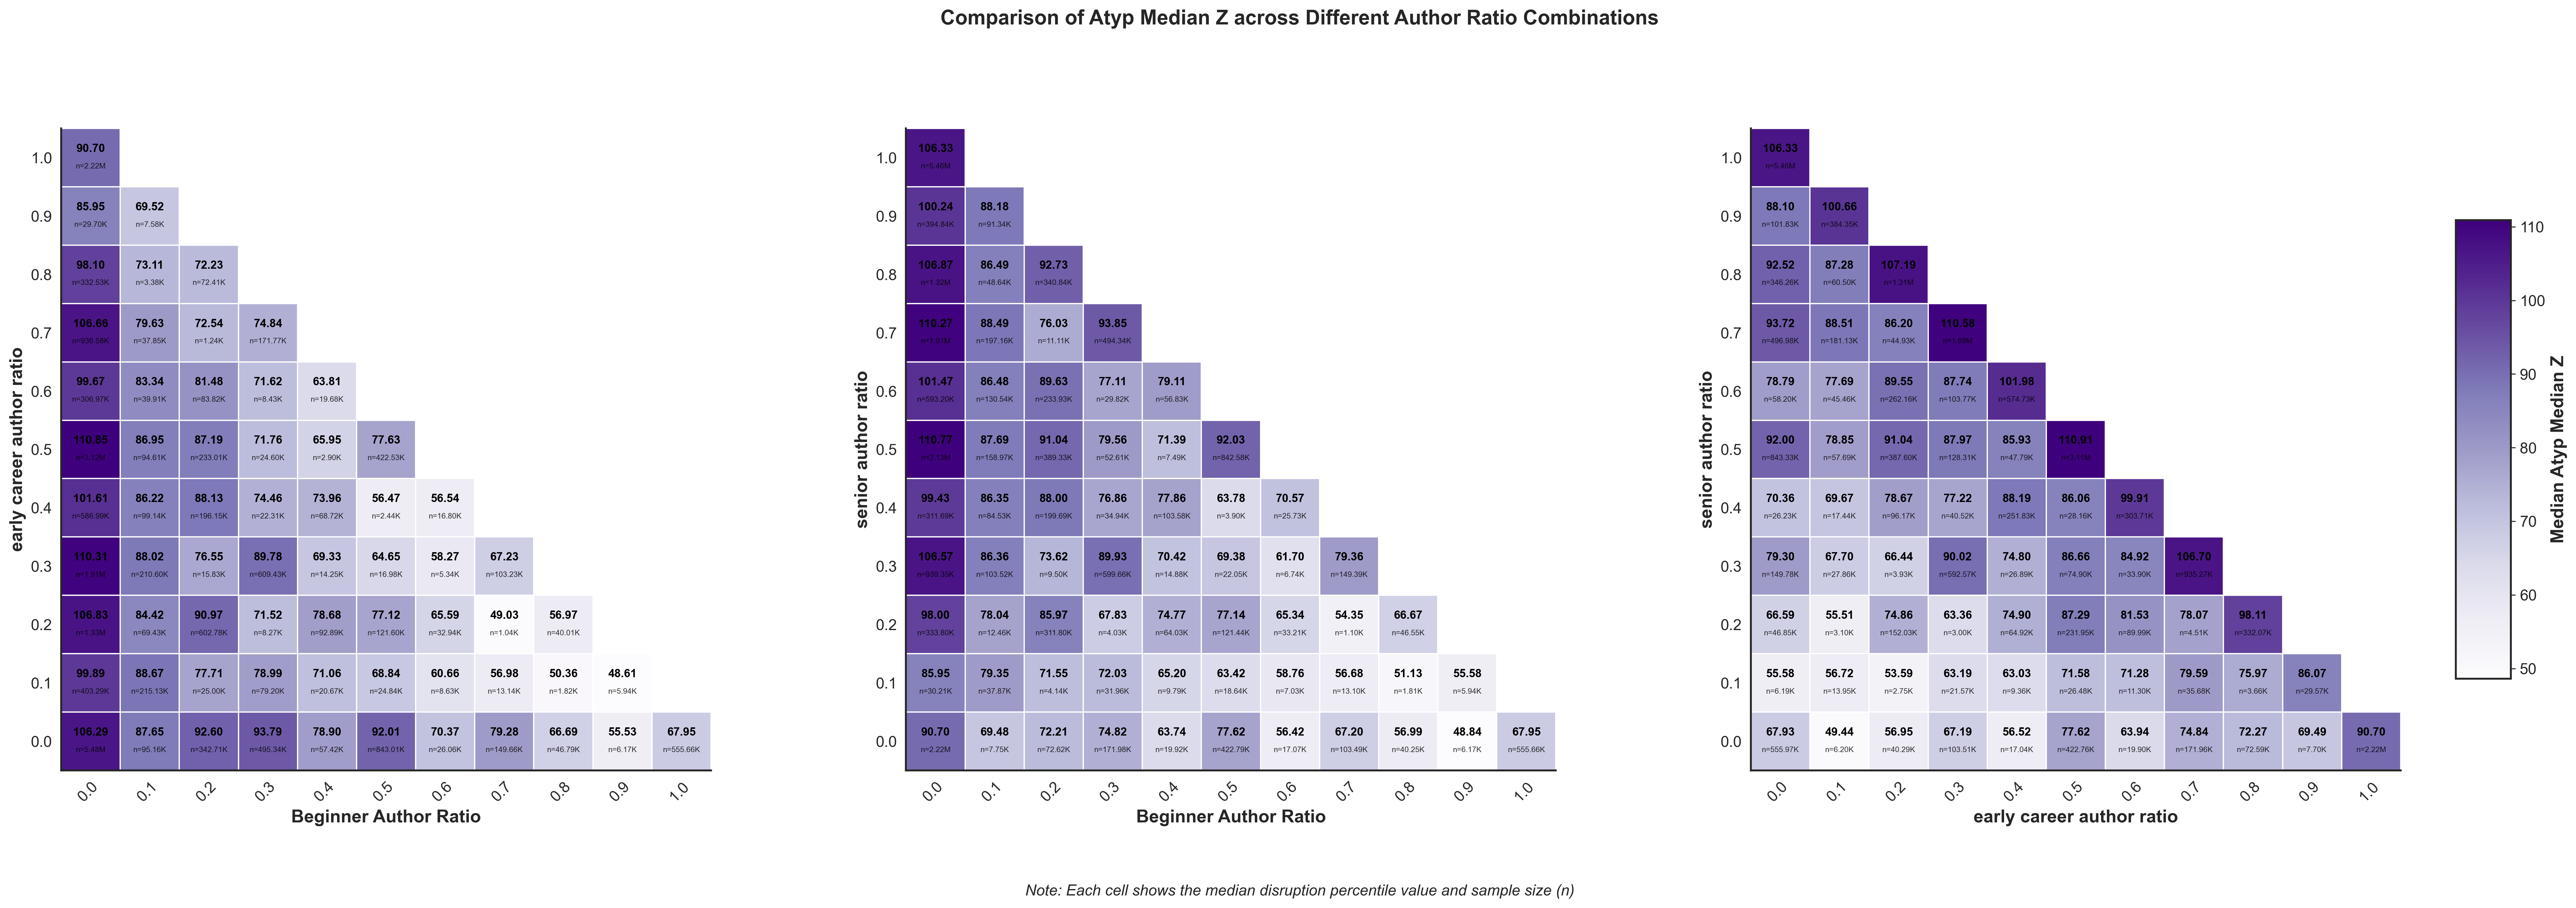

In [28]:
fig, axes, pivot_dfs = plot_expanded_disruption_heatmaps(
    final_df,
    target_column="Atyp_Median_Z",
    main_columns=[
        "first_time_author_ratio",
        "early_career_author_ratio",
        "senior_author_ratio",
    ],
    cmap="Purples",
    min_group_size=100,
    save_path="Final_Figures/Final_Atyp_Median_Z_heatmaps_by_author_ratios.pdf",
)

<Figure size 2400x1800 with 0 Axes>

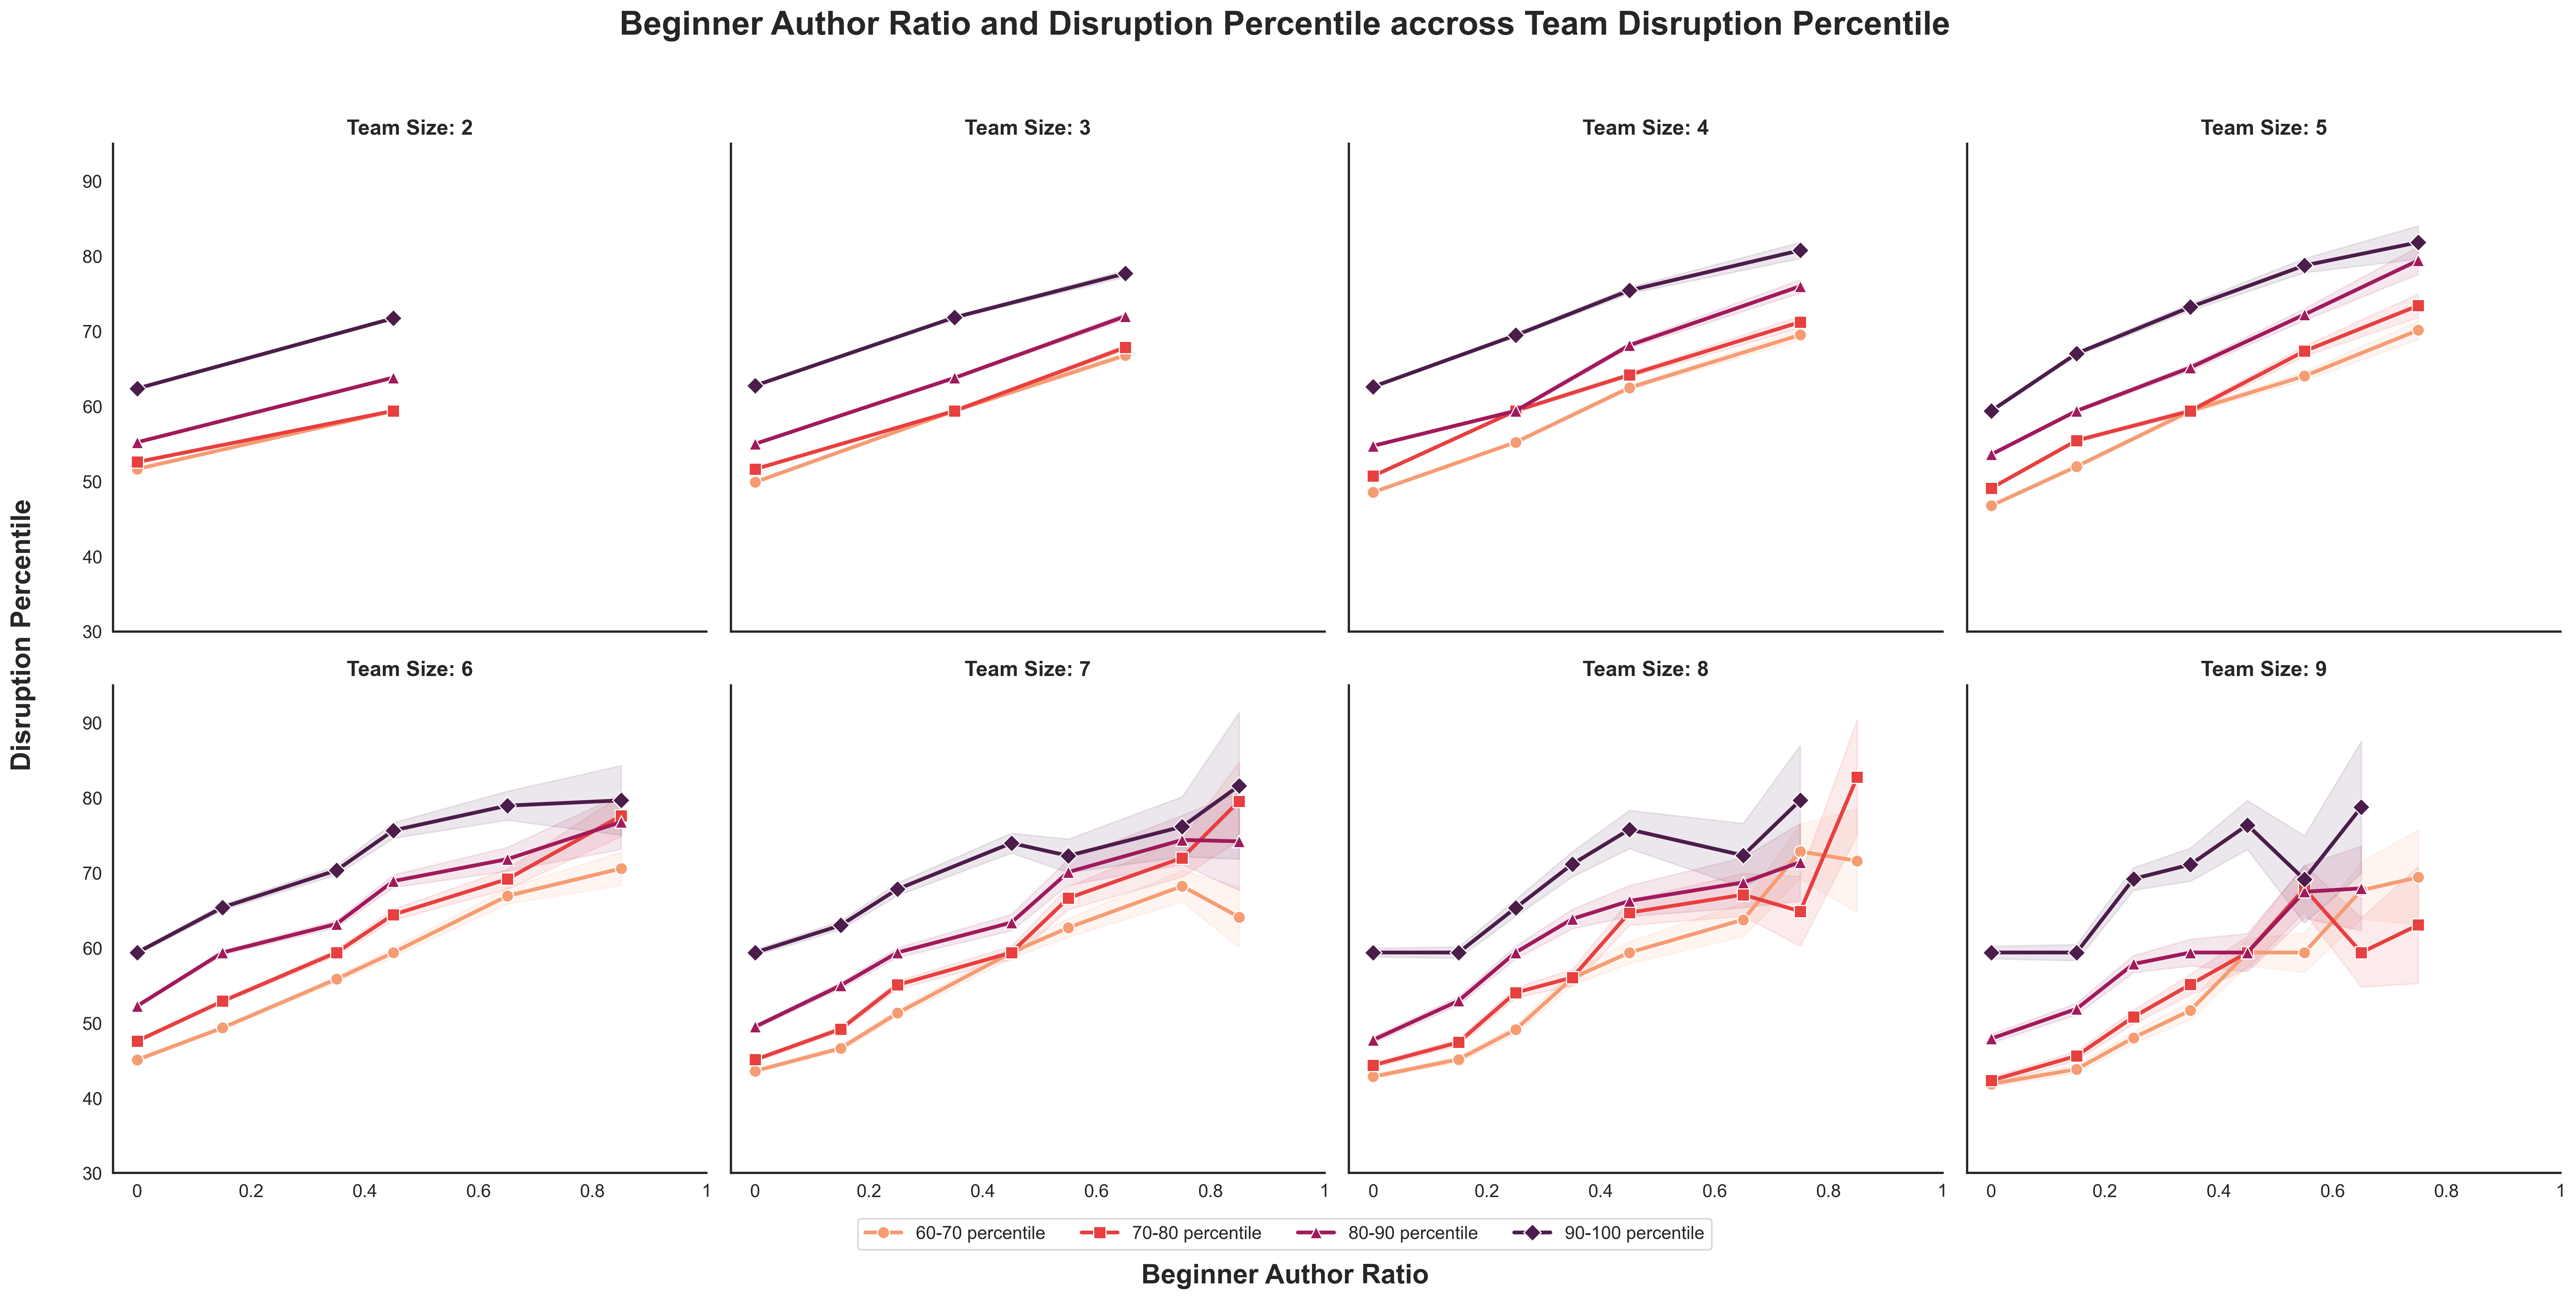

76066

In [29]:
def plot_firsttime_authors_by_coauthor_disruption(
    df,
    target_column="disruption_percentile",
    coauthor_group_column="co_authors_disruption_group",
    author_ratio_column="first_time_author_ratio",
    min_group_size=5,
    min_sample_threshold=50,
    n_bins=10,
    ci=95,
    ylim=(10, 90),
    show_ci=True,
    binning_method="equal",
    ci_method="sem",
    n_bootstrap=1000,
    team_sizes=None,
    coauthor_groups_to_plot=None,
    save_path=None,
):
    """
    Create a 2x4 grid of subplots, each showing the relationship between First-Time Author Ratio
    and disruption score across different co-author disruption groups for different team sizes.
    """
    setup_plotting_style()

    fig, axes = plt.subplots(2, 4, figsize=(24, 12), sharex=True, sharey=True, dpi=300)
    axes_flat = axes.flatten()

    # Get co-author disruption groups to plot
    if coauthor_groups_to_plot is None:
        coauthor_groups = sorted(df[coauthor_group_column].unique())
    else:
        coauthor_groups = [
            group
            for group in coauthor_groups_to_plot
            if group in df[coauthor_group_column].unique()
        ]

    # Check if any valid groups remain
    if not coauthor_groups:
        raise ValueError(
            f"None of the specified co-author groups found in the data. Available groups: {sorted(df[coauthor_group_column].unique())}"
        )

    # Use rocket color palette for disruption groups to show progression
    colors = sns.color_palette("rocket_r", n_colors=len(coauthor_groups))
    group_colors = {group: colors[i] for i, group in enumerate(coauthor_groups)}

    # Use different markers for each group
    marker_list = ["o", "s", "^", "D", "v"]
    markers = {
        group: marker_list[i % len(marker_list)]
        for i, group in enumerate(coauthor_groups)
    }

    if team_sizes is None:
        team_sizes = range(2, 10)  # 8 team sizes for 2x4 grid

    needed_columns = [
        author_ratio_column,
        target_column,
        "team_size",
        coauthor_group_column,
    ]
    df_slim = df[needed_columns].copy()

    for idx, team_size in enumerate(team_sizes):
        if idx >= 8:  # Only process first 8 team sizes for 2x4 grid
            break

        ax = axes_flat[idx]
        subset = df_slim[df_slim["team_size"] == team_size].copy()

        if len(subset) == 0:
            continue

        for group in coauthor_groups:
            group_subset = subset[subset[coauthor_group_column] == group].copy()

            if len(group_subset) == 0:
                continue

            results = []

            # Handle zero values separately
            zero_mask = group_subset[author_ratio_column] == 0
            zero_values = group_subset.loc[zero_mask, target_column]
            if len(zero_values) >= min_group_size:
                zero_median = zero_values.median()
                zero_std = zero_values.std()
                zero_sem = zero_std / np.sqrt(len(zero_values))

                if ci_method == "bootstrap":
                    boot = np.random.choice(
                        zero_values, (n_bootstrap, len(zero_values))
                    )
                    boot_meds = np.median(boot, axis=1)
                    lower = np.percentile(boot_meds, (100 - ci) / 2)
                    upper = np.percentile(boot_meds, 100 - (100 - ci) / 2)
                else:
                    z = 1.96
                    lower = zero_median - z * zero_sem
                    upper = zero_median + z * zero_sem

                results.append(
                    {
                        "x": 0,
                        "median": zero_median,
                        "count": len(zero_values),
                        "median_ci_lower": lower,
                        "median_ci_upper": upper,
                    }
                )

            del zero_mask, zero_values
            gc.collect()

            # Handle non-zero values
            values = group_subset[group_subset[author_ratio_column] > 0][
                [author_ratio_column, target_column]
            ].dropna()
            if len(values) == 0:
                continue

            # Binning
            if binning_method == "equal":
                bin_edges = np.linspace(0, 1, n_bins + 1)
                values["bin"] = pd.cut(
                    values[author_ratio_column], bins=bin_edges, include_lowest=True
                )
            else:
                values["bin"] = pd.qcut(
                    values[author_ratio_column], q=n_bins, duplicates="drop"
                )

            grouped = values.groupby("bin", observed=False)

            for bin_interval, group_data in grouped:
                if len(group_data) < min_group_size:
                    continue

                median = group_data[target_column].median()
                std = group_data[target_column].std()
                sem = std / np.sqrt(len(group_data))

                if ci_method == "bootstrap":
                    boot = np.random.choice(
                        group_data[target_column], (n_bootstrap, len(group_data))
                    )
                    boot_meds = np.median(boot, axis=1)
                    lower = np.percentile(boot_meds, (100 - ci) / 2)
                    upper = np.percentile(boot_meds, 100 - (100 - ci) / 2)
                else:
                    z = 1.96
                    lower = median - z * sem
                    upper = median + z * sem

                # Compute bin midpoint
                if binning_method == "equal":
                    midpoint = bin_interval.mid
                else:
                    midpoint = group_data[author_ratio_column].median()

                results.append(
                    {
                        "x": midpoint,
                        "median": median,
                        "count": len(group_data),
                        "median_ci_lower": lower,
                        "median_ci_upper": upper,
                    }
                )

            group_stats = pd.DataFrame(results)

            # Apply minimum sample threshold check
            filtered_stats = group_stats[group_stats["count"] >= min_sample_threshold]
            if filtered_stats.empty:
                continue

            # Plot the line
            sns.lineplot(
                x="x",
                y="median",
                data=filtered_stats,
                color=group_colors[group],
                marker=markers[group],
                markersize=8,
                linewidth=2.5,
                label=group if idx == 0 else None,  # Only add labels on first plot
                ax=ax,
            )

            if show_ci:
                ax.fill_between(
                    filtered_stats["x"],
                    filtered_stats["median_ci_lower"],
                    filtered_stats["median_ci_upper"],
                    alpha=0.1,
                    color=group_colors[group],
                )

            gc.collect()

        # Customize subplot
        ax.set_title(f"Team Size: {team_size}", fontweight="bold", fontsize=14)
        ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_xticklabels(["0", "0.2", "0.4", "0.6", "0.8", "1"])

        # Remove x and y axis labels from individual subplots
        ax.set_xlabel("")
        ax.set_ylabel("")

        if ylim:
            ax.set_ylim(ylim)

        sns.despine(ax=ax, top=True, right=True)

        # Clear memory
        del subset
        gc.collect()

    # Add a single legend for the entire figure
    handles, labels_list = axes_flat[0].get_legend_handles_labels()
    legend = fig.legend(
        handles,
        labels_list,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=min(
            len(coauthor_groups), 5
        ),  # Up to 5 columns for the 5 disruption groups
        frameon=True,
        fontsize=12,
    )

    # Remove individual legends
    for ax in axes_flat:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Handle empty subplots if less than 8 team sizes
    for i in range(len(team_sizes), 8):
        axes_flat[i].set_visible(False)

    # Add common axis labels
    fig.text(
        0.5,
        0.001,
        "Beginner Author Ratio",
        ha="center",
        fontsize=18,
        fontweight="bold",
    )

    ylabel_map = {
        "disruption_percentile": "Disruption Percentile",
        "C10": "C10",
        "c10_percentile": "C_10 Percentile",
    }

    if coauthor_group_column == "co_authors_disruption_group":
        title_var = "Team Disruption Percentile"
    elif coauthor_group_column == "co_authors_citation_group":
        title_var = "Team Citation Percentile"

    fig.text(
        0.01,
        0.5,
        ylabel_map.get(target_column, target_column),
        va="center",
        rotation="vertical",
        fontsize=18,
        fontweight="bold",
    )

    # Add title
    fig.suptitle(
        f"Beginner Author Ratio and {ylabel_map.get(target_column, target_column)} accross {title_var}",
        fontsize=22,
        fontweight="bold",
        y=0.98,
    )

    # Adjust layout
    plt.tight_layout(rect=[0.03, 0.05, 1, 0.95])

    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    return fig, axes


# Example usage:
coauthor_groups_to_plot = [
    "60-70 percentile",
    "70-80 percentile",
    "80-90 percentile",
    "90-100 percentile",
]

fig, axes = plot_firsttime_authors_by_coauthor_disruption(
    df=final_df,
    target_column="disruption_percentile",
    coauthor_group_column="co_authors_disruption_group",
    coauthor_groups_to_plot=coauthor_groups_to_plot,
    ylim=(30, 95),
    save_path="Final_Figures/Final_Disruption_by_First_Time_Author_Ratio_accross_coauthor_Disruption.pdf",
)
plt.show()
plt.close(fig)
del fig, axes
gc.collect()

In [31]:
def analyze_author_count_combinations(df, min_count=10, method="median"):
    """
    Analyze combinations of author counts and their relationship to disruption percentiles.

    This function:
    1. Groups by all 3 author count columns (no binning)
    2. For each combination, calculates statistics on disruption percentile based on method
    3. Sorts results by the chosen disruption percentile statistic (descending)

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing author count columns and disruption_percentile
    min_count : int, default=10
        Minimum number of records required in each combination
    method : str, default="median"
        Method to use for analysis, either "median" or "mean"

    Returns
    -------
    pandas.DataFrame
        Dataframe with columns for each author count, chosen disruption_percentile statistic, and N_Records
    """
    # Validate method parameter
    if method not in ["median", "mean"]:
        raise ValueError("Method must be either 'median' or 'mean'")

    # Define the author count columns
    count_columns = [
        "first_time_author_count",
        "early_career_author_count",
        "senior_author_count",
    ]

    # Step 1: Group by all 3 count columns
    grouped = df.groupby(count_columns)

    # Step 2: Calculate statistics for each group
    if method == "median":
        stats = (
            grouped["disruption_percentile"]
            .agg(["median", "mean", "count"])
            .reset_index()
        )
        main_stat_name = "Median_Disruption_Percentile"
        main_stat_column = "median"
    else:  # method == "mean"
        stats = grouped["disruption_percentile"].agg(["mean", "count"]).reset_index()
        main_stat_name = "Mean_Disruption_Percentile"
        main_stat_column = "mean"

    # Create the result dataframe
    result_columns = {
        "first_time_author_count": stats["first_time_author_count"],
        "early_career_author_count": stats["early_career_author_count"],
        "senior_author_count": stats["senior_author_count"],
        main_stat_name: stats[main_stat_column],
        "N_Records": stats["count"],
    }

    # Add mean disruption percentile if using median method
    if method == "median":
        result_columns["Mean_Disruption_Percentile"] = stats["mean"]

    combination_df = pd.DataFrame(result_columns)

    # Add team_size column
    combination_df["team_size"] = (
        combination_df["first_time_author_count"]
        + combination_df["early_career_author_count"]
        + combination_df["senior_author_count"]
    )

    # Filter by minimum count
    combination_df = combination_df[combination_df["N_Records"] >= min_count]

    # Step 3: Sort by chosen disruption statistic (descending)
    combination_df = combination_df.sort_values(main_stat_name, ascending=False)

    # Determine output columns
    output_columns = [
        "first_time_author_count",
        "early_career_author_count",
        "senior_author_count",
        main_stat_name,
        "N_Records",
    ]

    gc.collect()

    return combination_df[output_columns].sort_values(
        by=[main_stat_name, "first_time_author_count"], ascending=[False, True]
    )


def create_team_disruption_svg_direct(
    df,
    output_filename="Final_Figures/Final_team_disruption.svg",
    top_n=25,
    method="median",
):
    """
    Create an SVG file visualizing team composition and disruption percentiles using direct SVG generation.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing author count columns and disruption_percentile columns
    output_filename : str, default="team_disruption.svg"
        Filename for the output SVG file
    top_n : int, default=25
        Number of top teams to display
    method : str, default="median"
        Method used for analysis, either "median" or "mean"
    """
    import seaborn as sns
    import matplotlib.colors as mcolors

    # Determine correct disruption column based on method
    disruption_col = (
        f"{'Median' if method == 'median' else 'Mean'}_Disruption_Percentile"
    )

    # Take top N rows and sort by disruption
    plot_data = df.head(top_n).copy()
    plot_data = plot_data.sort_values(disruption_col, ascending=False).reset_index(
        drop=True
    )

    # Add team_size column if not present
    if "team_size" not in plot_data.columns:
        plot_data["team_size"] = (
            plot_data["first_time_author_count"]
            + plot_data["early_career_author_count"]
            + plot_data["senior_author_count"]
        )

    # Set up dimensions and margins
    width = 1000
    height = 800
    margin = {"top": 40, "right": 120, "bottom": 60, "left": 200}
    graph_width = width - margin["left"] - margin["right"]
    graph_height = height - margin["top"] - margin["bottom"]

    # Define career columns and map colors using viridis_r palette
    career_columns = [
        "first_time_author_count",
        "early_career_author_count",
        "senior_author_count",
    ]

    full_palette = sns.color_palette("viridis_r", 8)
    color_indices = [0, 1, 3, 5]
    selected_colors = [mcolors.to_hex(full_palette[i]) for i in color_indices]
    colors = {col: selected_colors[i] for i, col in enumerate(career_columns)}

    # Emoji mapping
    emoji_map = {
        "first_time_author_count": "🌱",
        "early_career_author_count": "🚀",
        "senior_author_count": "🧠",
    }

    # Disruption scale - dynamic based on data
    min_disruption = max(40, plot_data[disruption_col].min() - 5)
    max_disruption = min(75, plot_data[disruption_col].max() + 5)

    # Round to nearest 5 for cleaner ticks
    min_disruption = 5 * round(min_disruption / 5)
    max_disruption = 5 * round(max_disruption / 5)

    # Start SVG content
    svg_content = f"""<?xml version="1.0" encoding="UTF-8" standalone="no"?>
    <svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg">
        <rect x="0" y="0" width="{width}" height="{height}" fill="white"/>
        <style>
            .title {{ font-size: 18px; font-weight: bold; }}
            .axis-label {{ font-size: 12px; }}
            .tick-label {{ font-size: 10px; }}
            .bar {{ stroke: #888; stroke-width: 0.5; }}
            .bar-label {{ font-size: 10px; }}
            .legend {{ font-size: 10px; }}
        </style>

         <!-- Title (centered) -->
        <text class="title" x="{width/2}" y="25" text-anchor="middle">Career-Stage Based Team Composition and {method.title()} Disruption</text>

        <!-- X-axis label -->
        <text class="axis-label" x="{margin['left'] + graph_width/2}" y="{height - 15}" text-anchor="middle">{method.title()} Disruption Percentile</text>

        <!-- X-axis -->
        <line x1="{margin['left']}" y1="{height - margin['bottom']}" x2="{width - margin['right']}" y2="{height - margin['bottom']}" stroke="black" />
    """

    # Add X-axis ticks - dynamic based on min/max
    tick_range = range(int(min_disruption), int(max_disruption + 1), 5)
    for tick in tick_range:
        tick_x = (
            margin["left"]
            + ((tick - min_disruption) / (max_disruption - min_disruption))
            * graph_width
        )
        svg_content += f"""
        <line x1="{tick_x}" y1="{height - margin['bottom']}" x2="{tick_x}" y2="{height - margin['bottom'] + 5}" stroke="black" />
        <text class="tick-label" x="{tick_x}" y="{height - margin['bottom'] + 15}" text-anchor="middle">{tick}</text>
        """

    # Add bars for each team
    bar_height = graph_height / len(plot_data)
    bar_padding = bar_height * 0.2

    for i, (idx, row) in enumerate(plot_data.iterrows()):
        y_position = margin["top"] + i * bar_height + bar_height / 2
        bar_width = (
            (row[disruption_col] - min_disruption) / (max_disruption - min_disruption)
        ) * graph_width

        # Draw segmented bar
        start_x = margin["left"]
        team_size = row["team_size"]

        # Create emojis for y-tick
        team_emojis = ""
        for col in career_columns:
            if row[col] > 0:
                team_emojis += emoji_map[col] * int(row[col])

        # Add y-tick with emojis
        svg_content += f"""
        <text class="tick-label" x="{margin['left'] - 10}" y="{y_position}" text-anchor="end" dy="0.35em">{team_emojis}</text>
        """

        for col in career_columns:
            if row[col] > 0:
                segment_width = (row[col] / team_size) * bar_width
                svg_content += f"""
                <rect class="bar" x="{start_x}" y="{y_position - (bar_height - bar_padding*2)/2}"
                      width="{segment_width}" height="{bar_height - bar_padding*2}"
                      fill="{colors[col]}" />
                """

                # No emoji rendering here anymore - moved to y-ticks
                start_x += segment_width

        svg_content += f"""
        <text class="bar-label" x="{margin['left'] + bar_width + 5}" y="{y_position}" dy="0.35em">
            {row[disruption_col]:.2f} <tspan fill="#888">n = {row['N_Records']:,}</tspan>
        </text>
        """

    # Legend
    legend_y = height / 2 - margin["bottom"]
    legend_x = width - margin["right"] + 10

    svg_content += f"""
    <rect x="{legend_x - 10}" y="{legend_y - 10}" width="130" height="100" fill="white" stroke="#ddd" />
    """

    for i, col in enumerate(career_columns):
        label = col.replace("_author_count", "").replace("_", " ").title()
        y = legend_y + i * 20
        svg_content += f"""
        <rect x="{legend_x}" y="{y}" width="10" height="10" fill="{colors[col]}" />
        <text x="{legend_x + 15}" y="{y + 8}" class="legend">{emoji_map[col]} {label}</text>
        """

    # Close SVG
    svg_content += "</svg>"

    # Write to file
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(svg_content)

    print(f"SVG visualization saved to {output_filename}")

In [32]:
top_combination_based_on_median = analyze_author_count_combinations(
    final_df, 10000, method="median"
)
top_combination_based_on_mean = analyze_author_count_combinations(
    final_df, 10000, method="mean"
)

print("Total Number of Combinations: ", top_combination_based_on_mean.shape[0])

create_team_disruption_svg_direct(
    top_combination_based_on_mean,
    output_filename="Final_Figures/Final_team_disruption_based_on_mean.svg",
    top_n=25,
    method="mean",
)

create_team_disruption_svg_direct(
    top_combination_based_on_median,
    output_filename="Final_Figures/Final_team_disruption_based_on_median.svg",
    top_n=25,
    method="median",
)

Total Number of Combinations:  102
SVG visualization saved to Final_Figures/Final_team_disruption_based_on_mean.svg
SVG visualization saved to Final_Figures/Final_team_disruption_based_on_median.svg


In [33]:
top_50_mean = top_combination_based_on_mean.head(50)
top_50_mean.other_author_count = (
    top_50_mean.early_career_author_count + top_50_mean.senior_author_count
)

count = (top_50_mean.first_time_author_count >= top_50_mean.other_author_count).sum()
print("Count where beginner_author_count >= other_author_count:", count)

count = (top_50_mean.first_time_author_count > top_50_mean.other_author_count).sum()
print("Count where beginner_author_count > other_author_count:", count)

Count where beginner_author_count >= other_author_count: 23
Count where beginner_author_count > other_author_count: 14


/var/folders/rj/l30_wb7d3w7_tbx4gbz6lzzh0000gn/T/ipykernel_92250/845210911.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  top_50_mean.other_author_count = top_50_mean.early_career_author_count + top_50_mean.senior_author_count


# Highly disruptive papers by beginner-heavy teams are highly cited

<Figure size 2400x1800 with 0 Axes>

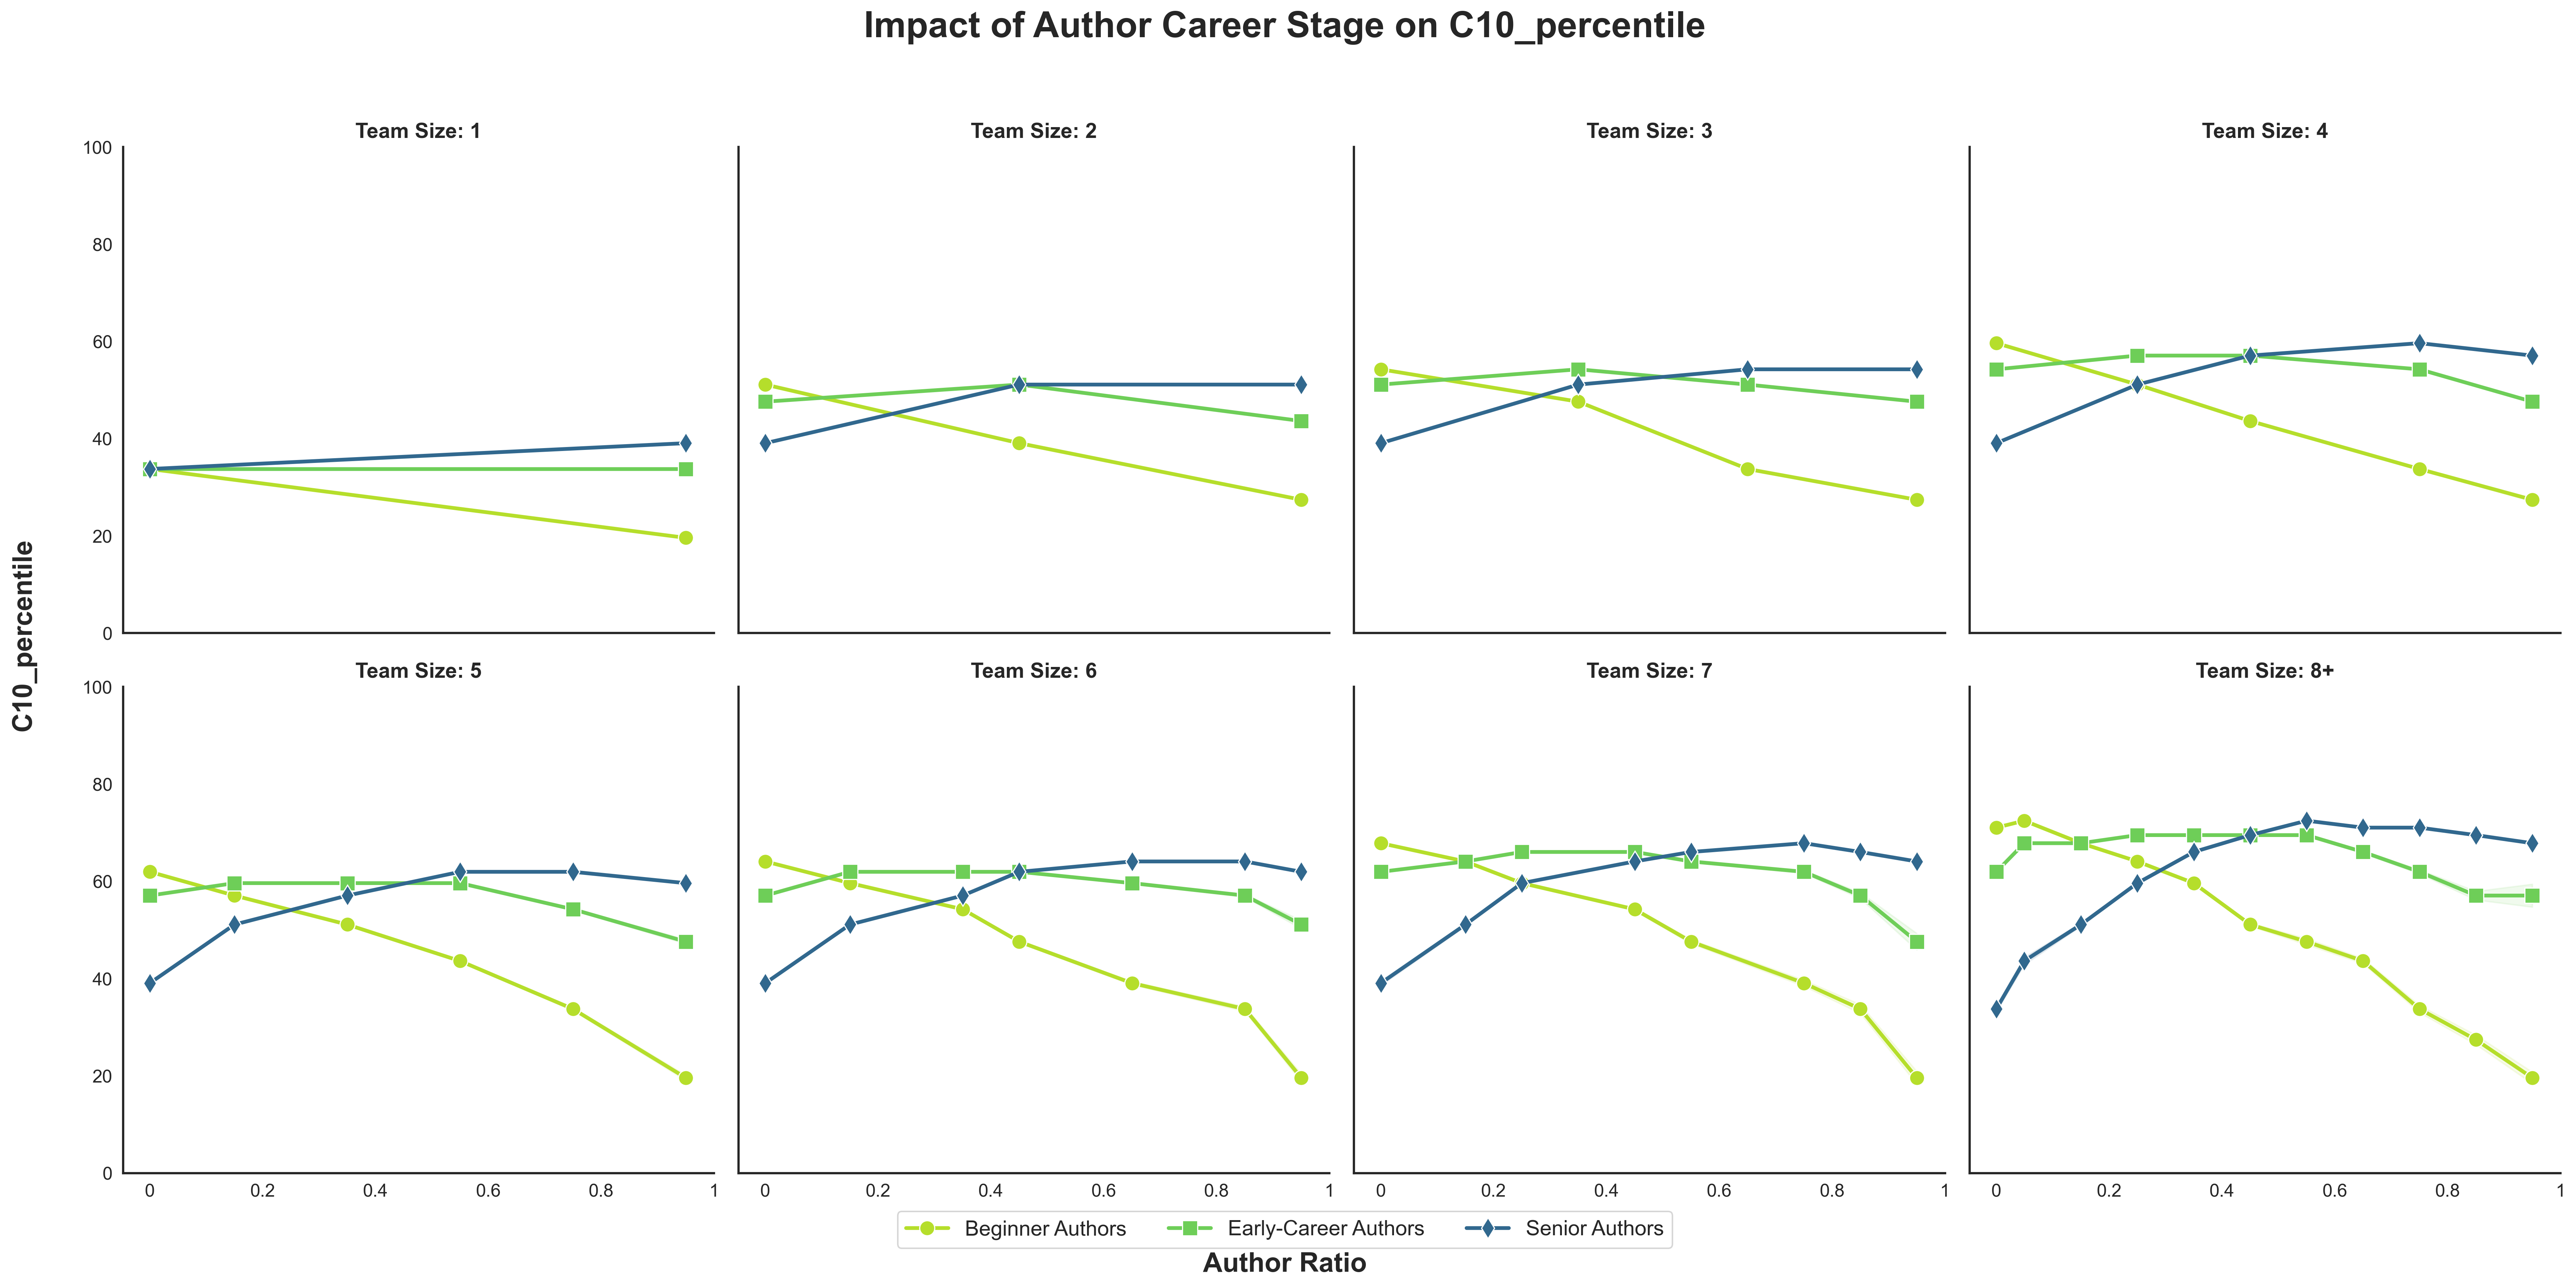

28262

In [34]:
fig, axes = plot_team_size_by_career_ratios_grid(
    df=final_df,
    target_column="C10_percentile",
    ylim=(0, 100),
    save_path="Final_Figures/Final_All_Career-Age_Ratio_And_C10.pdf",
)
plt.show()
plt.close(fig)
del fig, axes
gc.collect()

[1/10] cumulative: N=10% → rows=2804154  range=[90.000, 100.000]
[2/10] cumulative: N=20% → rows=5608268  range=[80.000, 100.000]
[3/10] cumulative: N=30% → rows=8412875  range=[70.000, 100.000]
[4/10] cumulative: N=40% → rows=10568255  range=[60.000, 100.000]
[5/10] cumulative: N=50% → rows=14021441  range=[50.000, 100.000]
[6/10] cumulative: N=60% → rows=16825748  range=[40.000, 100.000]
[7/10] cumulative: N=70% → rows=19630156  range=[30.000, 100.000]
[8/10] cumulative: N=80% → rows=22434151  range=[20.000, 100.000]
[9/10] cumulative: N=90% → rows=25238603  range=[10.000, 100.000]
[10/10] cumulative: N=100% → rows=28042889  range=[0.000, 100.000]

All thresholds processed. Intermediate files are in: intermediate_data

Figure saved to Final_Figures/Final_disruption_citation_correlation_cumulative_step10.pdf (dpi=300)


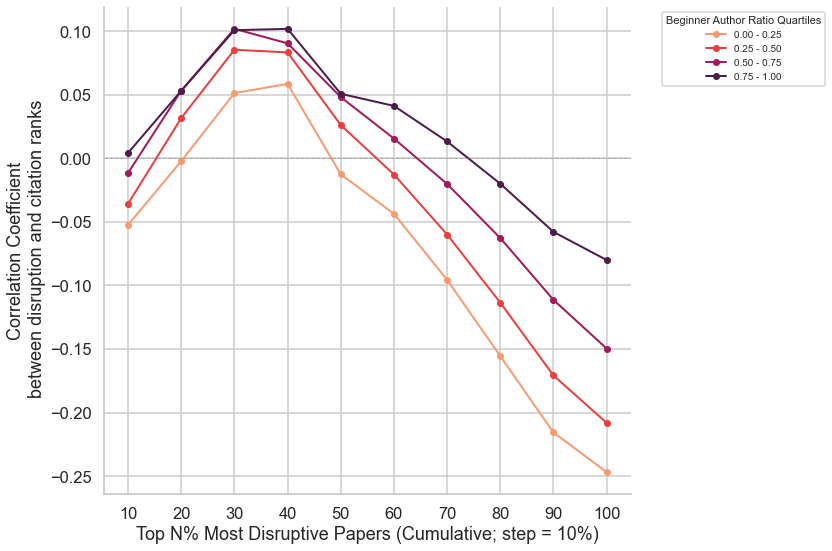


Summary Statistics:
Number of data points (rows across thresholds): 40
Groups analyzed: 4
Percentile thresholds covered: 10% to 100%

Correlation Summary by Group:
               min    max   mean    std
group                                  
0.00 - 0.25 -0.247  0.058 -0.072  0.106
0.25 - 0.50 -0.208  0.085 -0.038  0.101
0.50 - 0.75 -0.150  0.102 -0.005  0.084
0.75 - 1.00 -0.080  0.102  0.021  0.061


In [36]:
# --- Imports ---
import os, gc, glob, json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# --- Plot style helper ---
def setup_plotting_style():
    sns.set(context="talk", style="whitegrid")


# --- Core: compute correlations and stream results to disk (CUMULATIVE ONLY) ---
def compute_correlations_to_disk(
    final_df,
    out_dir="intermediate_data",
    min_rows_for_percentile=10,
    min_rows_per_group=5,
    overwrite=False,
    band_width=5,  # step size for cumulative thresholds: e.g., 5 -> [5,10,...,100]
    corr_method="pearson",  # "pearson", "spearman", or "kendall"
):
    """
    Computes groupwise correlations between disruption and citation percentiles for cumulative
    top-N% thresholds and writes tiny per-threshold CSVs to disk to save RAM.

    Cumulative selection for each threshold N:
        mask = disruption_percentile >= (100 - N)

    Thresholds on the x-axis are N = band_width, 2*band_width, ... , 100 (100 is always included).
    """
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    cols_needed = [
        "disruption_percentile",
        "citation_count_percentile",
        "first_time_author_ratio_group",
    ]
    missing = [c for c in cols_needed if c not in final_df.columns]
    if missing:
        raise ValueError(f"final_df is missing required columns: {missing}")

    # Keep only needed columns; coerce dtypes
    df = final_df[cols_needed].copy()
    df["disruption_percentile"] = pd.to_numeric(
        df["disruption_percentile"], errors="coerce"
    )
    df["citation_count_percentile"] = pd.to_numeric(
        df["citation_count_percentile"], errors="coerce"
    )
    df["first_time_author_ratio_group"] = df["first_time_author_ratio_group"].astype(
        "category"
    )

    # --- Cumulative thresholds controlled by band_width; always include 100 ---
    if band_width <= 0 or band_width > 100:
        raise ValueError("band_width must be in (0, 100].")
    x_ticks = list(range(band_width, 100, band_width))
    if 100 not in x_ticks:
        x_ticks.append(100)

    total = len(x_ticks)
    for idx, N in enumerate(x_ticks, 1):
        csv_path = Path(out_dir) / f"corr_p{N:03d}.csv"
        meta_path = Path(out_dir) / f"meta_p{N:03d}.json"

        if csv_path.exists() and meta_path.exists() and not overwrite:
            print(f"[{idx}/{total}] cumulative: N={N}%  — skip (already computed)")
            continue

        # --- Cumulative selection ---
        low = 100 - N
        mask = df["disruption_percentile"] >= low
        top_df = df[mask]

        # Progress
        range_str = f"[{low:.3f}, 100.000]"
        print(
            f"[{idx}/{total}] cumulative: N={N}% → rows={len(top_df)}  range={range_str}"
        )

        # Skip small selections to avoid noisy correlations
        if len(top_df) < min_rows_for_percentile:
            pd.DataFrame(
                columns=["percentile_threshold", "group", "correlation", "sample_size"]
            ).to_csv(csv_path, index=False)
            meta = {
                "percentile_threshold": N,
                "selection": "cumulative",
                "cut_low": float(low),
                "cut_high": 100.0,
                "rows_in_top": int(len(top_df)),
                "skipped": True,
                "reason": f"rows_in_top < {min_rows_for_percentile}",
                "corr_method": corr_method,
                "min_rows_per_group": int(min_rows_per_group),
                "band_width": band_width,
            }
            meta_path.write_text(json.dumps(meta, indent=2))
            del top_df
            gc.collect()
            continue

        # --- Groupwise correlation safely (no DeprecationWarning) ---
        def _safe_corr_vals(g):
            if len(g) >= min_rows_per_group:
                return g["disruption_percentile"].corr(
                    g["citation_count_percentile"], method=corr_method
                )
            return np.nan

        correlations = top_df.groupby("first_time_author_ratio_group", observed=True)[
            ["disruption_percentile", "citation_count_percentile"]
        ].apply(
            _safe_corr_vals
        )  # -> Series indexed by group

        # Precompute group sizes once
        group_sizes = top_df["first_time_author_ratio_group"].value_counts()

        # Collect rows (only non-NaN correlations)
        rows = []
        for group, corr in correlations.items():
            if pd.notna(corr):
                rows.append(
                    {
                        "percentile_threshold": N,
                        "group": str(group),
                        "correlation": float(corr),
                        "sample_size": int(group_sizes.get(group, 0)),
                    }
                )

        # Write out the tiny CSV
        pd.DataFrame(
            rows,
            columns=["percentile_threshold", "group", "correlation", "sample_size"],
        ).to_csv(csv_path, index=False)

        # Meta JSON
        meta = {
            "percentile_threshold": N,
            "selection": "cumulative",
            "cut_low": float(low),
            "cut_high": 100.0,
            "rows_in_top": int(len(top_df)),
            "groups_in_result": int(len(rows)),
            "skipped": len(rows) == 0,
            "corr_method": corr_method,
            "min_rows_per_group": int(min_rows_per_group),
            "band_width": band_width,
        }
        meta_path.write_text(json.dumps(meta, indent=2))

        # Clean up
        del top_df, correlations, rows
        gc.collect()

    print("\nAll thresholds processed. Intermediate files are in:", out_dir)


# --- Helper: load all tiny CSVs into one DataFrame ---
def _load_results_df(out_dir="intermediate_data"):
    files = sorted(glob.glob(os.path.join(out_dir, "corr_p*.csv")))
    if not files:
        return None
    parts = [pd.read_csv(f) for f in files]
    if not parts:
        return None
    res = pd.concat(parts, ignore_index=True)
    return res


# --- Plot + save PDF (labels reflect cumulative mode & band_width step) ---
def load_results_and_plot_raiyan(
    out_dir="intermediate_data", fig_dir="Figures", band_width=5, fig_name=None
):
    """
    Loads the per-threshold correlation snippets (cumulative top-N%) and plots one line per group.
    Saves a high-res PDF (dpi=300) to `fig_dir`.
    """
    setup_plotting_style()

    results_df = _load_results_df(out_dir)
    if results_df is None or results_df.empty:
        print(f"No valid correlations found under {out_dir}/.")
        return

    palette = sns.color_palette("rocket_r", n_colors=results_df["group"].nunique())
    plt.figure(figsize=(12, 8))

    for group, color in zip(sorted(results_df["group"].dropna().unique()), palette):
        gdf = results_df[results_df["group"] == group].sort_values(
            "percentile_threshold"
        )
        if not gdf.empty:
            plt.plot(
                gdf["percentile_threshold"],
                gdf["correlation"],
                marker="o",
                label=group,
                color=color,
                linewidth=2,
                markersize=6,
            )

    plt.xlabel(f"Top N% Most Disruptive Papers (Cumulative; step = {band_width}%)")
    plt.ylabel("Correlation Coefficient\n between disruption and citation ranks")
    #     plt.title("Disruption–Citation Correlation by First-time Author Ratio Groups\nAcross Cumulative Percentile Thresholds")
    plt.axhline(y=0, color="gray", linestyle="--", alpha=0.5, linewidth=1)
    plt.legend(
        title="Beginner Author Ratio Quartiles",
        title_fontsize=11,
        fontsize=10,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    # x ticks: use thresholds present; thin if many
    xvals = sorted(results_df["percentile_threshold"].unique())
    step = max(1, len(xvals) // 10)
    plt.xticks(xvals[::step])

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()

    # --- Save as PDF (dpi=300) ---
    Path(fig_dir).mkdir(parents=True, exist_ok=True)
    if fig_name is None:
        fig_name = (
            f"Final_disruption_citation_correlation_cumulative_step{band_width}.pdf"
        )
    out_path = Path(fig_dir) / fig_name
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"\nFigure saved to {out_path} (dpi=300)")

    plt.show()

    # Console summary
    print("\nSummary Statistics:")
    print(f"Number of data points (rows across thresholds): {len(results_df)}")
    print(f"Groups analyzed: {results_df['group'].nunique()}")
    print(
        f"Percentile thresholds covered: {int(np.nanmin(results_df['percentile_threshold']))}% to {int(np.nanmax(results_df['percentile_threshold']))}%"
    )

    correlation_summary = (
        results_df.groupby("group", dropna=True)["correlation"]
        .agg(["min", "max", "mean", "std"])
        .round(3)
    )
    print("\nCorrelation Summary by Group:")
    print(correlation_summary)


# --- Example usage (cumulative, step=5 -> thresholds 5,10,...,100) ---
compute_correlations_to_disk(
    final_df,
    out_dir="intermediate_data",
    min_rows_for_percentile=10,
    min_rows_per_group=5,
    overwrite=True,
    band_width=10,  # step size for cumulative thresholds
    corr_method="spearman",  # or "pearson"/"kendall"
)
load_results_and_plot_raiyan(
    out_dir="intermediate_data", fig_dir="Final_Figures", band_width=10
)

In [37]:
# ========= Quartile-line significance tests (cumulative, Fisher r-to-z) =========
import os, gc, glob
from pathlib import Path
import numpy as np
import pandas as pd
from math import atanh, isfinite, erfc, sqrt


# Load the tiny per-threshold CSVs
def _load_results_df(out_dir="intermediate_data"):
    files = sorted(glob.glob(os.path.join(out_dir, "corr_p*.csv")))
    if not files:
        return None
    parts = [pd.read_csv(f) for f in files]
    if not parts:
        return None
    return pd.concat(parts, ignore_index=True)


def _safe_atanh(r, eps=1e-12):
    if pd.isna(r):
        return np.nan
    # Guard against |r|=1.0
    r = float(np.clip(r, -1 + eps, 1 - eps))
    return atanh(r)


def _p_two_sided_from_z(z):
    if not isfinite(z):
        return np.nan
    # two-sided p = 2 * (1 - Phi(|z|)) = erfc(|z|/sqrt(2))
    return erfc(abs(z) / sqrt(2.0))


def _holm_stepdown(pvals):
    p = np.asarray(pvals, dtype=float)
    order = np.argsort(p)
    adj = np.empty_like(p)
    running_max = 0.0
    m = len(p)
    for i, idx in enumerate(order):
        raw_adj = (m - i) * p[idx]
        running_max = max(running_max, raw_adj)
        adj[idx] = min(1.0, running_max)
    return adj


def _fdr_bh(pvals):
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    p_sorted = p[order]
    q = np.empty_like(p)
    running_min = 1.0
    for i in range(m - 1, -1, -1):
        q_i = p_sorted[i] * m / (i + 1)
        running_min = min(running_min, q_i)
        q[i] = min(1.0, running_min)
    out = np.empty_like(p)
    out[order] = q
    return out


def _star(p):
    if pd.isna(p):
        return "n/a"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def run_quartile_line_tests_cumulative(
    out_dir="intermediate_data",
    results_dir="Results",
    table_name="PNAS_quartile_line_tests_step10",
    expected_quartiles=("0.00 - 0.25", "0.25 - 0.50", "0.50 - 0.75", "0.75 - 1.00"),
    step_filter=10,  # only use thresholds that are multiples of this (e.g., 10 → 10,20,...,100)
    p_floor=1e-300,
):
    """
    Pairwise Fisher r-to-z tests comparing quartile correlation lines at each cumulative threshold.
    Adjusts p-values per threshold across the 6 pairwise comparisons (Holm + BH/FDR).
    Prints PNAS-ready text and saves CSV + LaTeX tables.

    Returns
    -------
    per_threshold_df : long-form DataFrame of all tests across thresholds
    """
    Path(results_dir).mkdir(parents=True, exist_ok=True)
    res = _load_results_df(out_dir)
    if res is None or res.empty:
        print(f"[ERROR] No correlation files found under {out_dir}/.")
        return None

    # Keep only thresholds that match your cumulative step (e.g., 10,20,...,100)
    thresholds = sorted(
        t
        for t in res["percentile_threshold"].dropna().unique().tolist()
        if int(t) % int(step_filter) == 0
    )

    # Standardize quartile ordering if labels are present
    # Fallback: sort alphabetically
    if set(expected_quartiles).issubset(set(res["group"].unique())):
        q_order = list(expected_quartiles)
    else:
        q_order = sorted(res["group"].dropna().unique().tolist())

    rows = []
    for N in thresholds:
        sub = res[res["percentile_threshold"] == N].copy()

        # Map quartile -> (r, n)
        info = {}
        for _, row in sub.iterrows():
            q = str(row["group"])
            info[q] = (float(row["correlation"]), int(row.get("sample_size", np.nan)))

        # Generate all 6 pairwise comparisons among the 4 quartiles
        pairs = []
        for i in range(len(q_order)):
            for j in range(i + 1, len(q_order)):
                a, b = q_order[i], q_order[j]
                r1, n1 = info.get(a, (np.nan, np.nan))
                r2, n2 = info.get(b, (np.nan, np.nan))

                if (
                    not (isfinite(r1) and isfinite(r2))
                    or (n1 is None)
                    or (n2 is None)
                    or (n1 < 4)
                    or (n2 < 4)
                ):
                    z = np.nan
                    p = np.nan
                else:
                    z1 = _safe_atanh(r1)
                    z2 = _safe_atanh(r2)
                    denom = sqrt(1.0 / (n1 - 3) + 1.0 / (n2 - 3))
                    z = (z1 - z2) / denom if denom > 0 else np.nan
                    p = _p_two_sided_from_z(z)

                pairs.append((a, b, r1, n1, r2, n2, z, p))

        # Multiple-testing adjust per threshold (6 tests)
        pvals = [p for *_, p in pairs]
        holm = _holm_stepdown(pvals)
        fdr = _fdr_bh(pvals)

        # Collect rows
        for (a, b, r1, n1, r2, n2, z, p), p_holm, q_bh in zip(pairs, holm, fdr):
            rows.append(
                {
                    "percentile_threshold": int(N),
                    "quartile_a": a,
                    "quartile_b": b,
                    "r_a": r1,
                    "n_a": n1,
                    "r_b": r2,
                    "n_b": n2,
                    "z_diff": z,
                    "p_raw": p,
                    "p_holm": p_holm,
                    "q_bh": q_bh,
                }
            )

    per_threshold = pd.DataFrame(rows)

    # Pretty rounding and p-floor for printing
    printable = per_threshold.copy()
    for col in ["r_a", "r_b", "z_diff", "p_raw", "p_holm", "q_bh"]:
        printable[col] = printable[col].astype(float)

    def _fmt_p(x):
        if not isfinite(x) or pd.isna(x):
            return "n/a"
        return f"<{p_floor:.0e}" if x < p_floor else f"{x:.3g}"

    # ---- PNAS-style console printout ----
    print(
        "\nPairwise Fisher r-to-z tests for quartile correlation lines (cumulative thresholds)"
    )
    print(f"Thresholds used (step={step_filter}%): {thresholds}\n")

    # For each threshold, print the 6 pairwise results (Holm-adjusted)
    for N in thresholds:
        sub = printable[printable["percentile_threshold"] == N].copy()
        if sub.empty:
            continue
        # Optional: show approximate per-quartile n at this N
        ns = {}
        for q in q_order:
            qsub = per_threshold[
                (per_threshold["percentile_threshold"] == N)
                & (
                    (per_threshold["quartile_a"] == q)
                    | (per_threshold["quartile_b"] == q)
                )
            ]
            # pick first available n for that quartile at this N
            n_vals = []
            if not qsub.empty:
                n_vals += qsub["n_a"].dropna().tolist()
                n_vals += qsub["n_b"].dropna().tolist()
            ns[q] = int(max(n_vals)) if n_vals else 0

        print(
            f"— Cumulative threshold N={N}% (disruption ≥ {100-N:.0f}th percentile) —"
        )
        print(
            "Quartile sizes (n): " + " / ".join([f"{q}:{ns.get(q,0)}" for q in q_order])
        )

        # Order pairs in a nice fixed way
        sub = (
            sub.set_index(["quartile_a", "quartile_b"])
            .reindex(
                [
                    (q_order[0], q_order[1]),
                    (q_order[0], q_order[2]),
                    (q_order[0], q_order[3]),
                    (q_order[1], q_order[2]),
                    (q_order[1], q_order[3]),
                    (q_order[2], q_order[3]),
                ]
            )
            .reset_index()
        )

        for _, r in sub.iterrows():
            a, b = r["quartile_a"], r["quartile_b"]
            z = r["z_diff"]
            p = r["p_raw"]
            p_h = r["p_holm"]
            q = r["q_bh"]
            ra, rb = r["r_a"], r["r_b"]
            # stars by Holm-adjusted p
            stars = _star(p_h)
            print(
                f"  {a} vs {b}: Δz={z:.3f}, p={_fmt_p(p)}, Holm p={_fmt_p(p_h)} {stars}; "
                f"r_a={ra:.3f}, r_b={rb:.3f}, n_a={int(r['n_a'])}, n_b={int(r['n_b'])}"
            )
        print("")

    # ---- Across-threshold summary (how often pairs are significant after Holm) ----
    print("Across-threshold summary (Holm-adjusted p<0.05):")
    pair_keys = sorted({(a, b) for a in q_order for b in q_order if a < b})
    for a, b in pair_keys:
        sub = per_threshold[
            (per_threshold["quartile_a"] == a) & (per_threshold["quartile_b"] == b)
        ]
        k = int((sub["p_holm"] < 0.05).sum())
        total = sub.shape[0]
        # median correlation difference (r_a - r_b) across thresholds (directional context)
        med_dr = (sub["r_a"] - sub["r_b"]).median()
        print(
            f"  {a} vs {b}: {k}/{total} thresholds significant; median Δr={med_dr:.3f}"
        )

    # ---- Save tables ----
    csv_path = Path(results_dir) / f"{table_name}.csv"
    per_threshold.to_csv(csv_path, index=False)

    # LaTeX (compact, PNAS-SI style)
    # Limit columns and round for readability
    tex_cols = [
        "percentile_threshold",
        "quartile_a",
        "quartile_b",
        "r_a",
        "r_b",
        "n_a",
        "n_b",
        "z_diff",
        "p_raw",
        "p_holm",
        "q_bh",
    ]
    tex_df = per_threshold[tex_cols].copy()
    for c in ["r_a", "r_b", "z_diff", "p_raw", "p_holm", "q_bh"]:
        tex_df[c] = tex_df[c].astype(float).round(4)
    latex = tex_df.to_latex(
        index=False,
        escape=True,
        caption="Pairwise Fisher r-to-z tests comparing correlation coefficients across quartiles at each cumulative threshold (step = %d). Holm- and BH-adjusted p-values reported per threshold."
        % step_filter,
        label="tab:quartile_line_tests",
    )
    tex_path = Path(results_dir) / f"{table_name}.tex"
    Path(tex_path).write_text(latex)

    print(f"\nSaved CSV: {csv_path}")
    print(f"Saved LaTeX: {tex_path}")
    gc.collect()
    return per_threshold

In [38]:
# After you've computed the cumulative correlations with step=10:
# compute_correlations_to_disk(final_df, band_width=10, corr_method="spearman", ...)

tests_df = run_quartile_line_tests_cumulative(
    out_dir="intermediate_data",
    results_dir="Final_Figures",
    table_name="Final_quartile_line_tests_step10",
    expected_quartiles=("0.00 - 0.25", "0.25 - 0.50", "0.50 - 0.75", "0.75 - 1.00"),
    step_filter=10,  # match your cumulative step
    p_floor=1e-300,
)


Pairwise Fisher r-to-z tests for quartile correlation lines (cumulative thresholds)
Thresholds used (step=10%): [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

— Cumulative threshold N=10% (disruption ≥ 90th percentile) —
Quartile sizes (n): 0.00 - 0.25:2029021 / 0.25 - 0.50:2029021 / 0.50 - 0.75:2029021 / 0.75 - 1.00:2029021
  0.00 - 0.25 vs 0.25 - 0.50: Δz=-10.407, p=2.3e-25, Holm p=6.9e-25 ***; r_a=-0.053, r_b=-0.036, n_a=2029021, n_b=478368
  0.00 - 0.25 vs 0.50 - 0.75: Δz=-12.071, p=1.51e-33, Holm p=6.03e-33 ***; r_a=-0.053, r_b=-0.012, n_a=2029021, n_b=90829
  0.00 - 0.25 vs 0.75 - 1.00: Δz=-24.505, p=1.29e-132, Holm p=7.76e-132 ***; r_a=-0.053, r_b=0.004, n_a=2029021, n_b=205936
  0.25 - 0.50 vs 0.50 - 0.75: Δz=-6.689, p=2.24e-11, Holm p=4.48e-11 ***; r_a=-0.036, r_b=-0.012, n_a=478368, n_b=90829
  0.25 - 0.50 vs 0.75 - 1.00: Δz=-15.157, p=6.81e-52, Holm p=3.41e-51 ***; r_a=-0.036, r_b=0.004, n_a=478368, n_b=205936
  0.50 - 0.75 vs 0.75 - 1.00: Δz=-3.951, p=7.8e-05, Holm p=7.8e-05 *

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import gc


def plot_citation_share_by_disruption_quartiles(
    df,
    disruption_col="disruption_percentile",
    citation_col="citation_count",
    band_width=5,  # non-overlapping bands; must divide 100
    quartile_column="first_time_author_ratio_group",  # your 4-bin column (e.g., "0.00-0.25", ...)
    normalize="within_quartile",  # "within_quartile" (alias: "within_group") or "global"
    fig_dir="Figures",
    fig_name=None,
    dpi=300,
    y_pad_frac=0.08,  # ~8% dynamic padding around data range
):
    """
    Non-cumulative plot: x = non-overlapping disruption 'bands' (tail slices),
    y = proportion of citations captured in each band, stratified by author-ratio QUARTILES.

    Bands (for band_width=5):
      N=5  -> [95,100]
      N=10 -> [90,95)
      ...
      N=100-> [0,5]   (topmost includes 100; others are half-open on the right)

    Normalization:
      - "within_quartile" (alias: "within_group"):
          For each quartile q,
            share(q, band) = citations_in_band_from_q / total_citations_of_q.
          Each quartile’s line sums to 1 across all bands. Best for comparing how
          *each quartile* distributes its own citations across disruption levels.
      - "global":
          share(q, band) = citations_in_band_from_q / total_citations_in_dataset.
          Lines sum to the global citation fraction for each quartile; the “Overall”
          (if plotted alone) would sum to 1 across bands.

    Returns
    -------
    result_df : pd.DataFrame with columns
      [threshold, band_low, band_high, quartile, citations_in_band, denom, share]
    """
    if 100 % band_width != 0:
        raise ValueError("band_width must divide 100 (e.g., 1,2,4,5,10,20,25,50).")

    # Validate / prepare columns
    if citation_col not in df.columns:
        if "citation_count_percentile" in df.columns:
            print(
                f"[WARN] '{citation_col}' not found; using 'citation_count_percentile' as a proxy."
            )
            citation_col = "citation_count_percentile"
        else:
            raise ValueError(
                f"'{citation_col}' not found and no 'citation_count_percentile' fallback available."
            )

    cols = [disruption_col, citation_col]
    if quartile_column is not None:
        cols.append(quartile_column)

    work = df[cols].copy()
    work[disruption_col] = pd.to_numeric(work[disruption_col], errors="coerce")
    work[citation_col] = pd.to_numeric(work[citation_col], errors="coerce")
    if quartile_column is not None:
        work[quartile_column] = work[quartile_column].astype("category")

    # Normalization setup
    norm_mode = normalize.lower()
    if norm_mode == "within_group":
        norm_mode = "within_quartile"

    if norm_mode == "global":
        denom_global = np.nansum(work[citation_col].to_numpy())
        denom_per_quartile = None
    elif norm_mode == "within_quartile":
        if quartile_column is not None:
            denom_per_quartile = work.groupby(quartile_column, observed=True)[
                citation_col
            ].sum()
        else:
            denom_per_quartile = pd.Series(
                {"Overall": np.nansum(work[citation_col].to_numpy())}
            )
        denom_global = None
    else:
        raise ValueError(
            "normalize must be 'within_quartile' (or 'within_group') or 'global'."
        )

    thresholds = list(range(band_width, 101, band_width))
    rows = []

    for idx, N in enumerate(thresholds, 1):
        low = 100 - N
        high = 100 - (N - band_width)

        # mask for non-overlapping band
        if high >= 100:
            mask = (work[disruption_col] >= low) & (work[disruption_col] <= 100)
        else:
            mask = (work[disruption_col] >= low) & (work[disruption_col] < high)

        band_df = work[mask]

        if quartile_column is not None:
            # per-quartile aggregation
            band_sum = band_df.groupby(quartile_column, observed=True)[
                citation_col
            ].sum()
            all_quarts = work[quartile_column].cat.categories
            band_sum = band_sum.reindex(all_quarts, fill_value=0.0)

            for q, num in band_sum.items():
                if norm_mode == "global":
                    denom = denom_global if denom_global > 0 else np.nan
                else:
                    denom = denom_per_quartile.get(q, np.nan)
                share = (num / denom) if (denom and denom > 0) else np.nan
                rows.append(
                    {
                        "threshold": N,
                        "band_low": low,
                        "band_high": high,
                        "quartile": str(q),
                        "citations_in_band": float(num),
                        "denom": float(denom) if pd.notna(denom) else np.nan,
                        "share": float(share) if pd.notna(share) else np.nan,
                    }
                )
        else:
            # overall only (no quartile stratification)
            num = float(np.nansum(band_df[citation_col].to_numpy()))
            denom = (
                denom_global
                if norm_mode == "global"
                else float(np.nansum(work[citation_col].to_numpy()))
            )
            share = (num / denom) if (denom and denom > 0) else np.nan
            rows.append(
                {
                    "threshold": N,
                    "band_low": low,
                    "band_high": high,
                    "quartile": "Overall",
                    "citations_in_band": num,
                    "denom": denom,
                    "share": float(share) if pd.notna(share) else np.nan,
                }
            )

        # progress
        rb = "]" if high >= 100 else ")"
        print(
            f"[{idx}/{len(thresholds)}] band({band_width}%) non-overlap: N={N}% → rows={len(band_df)}  "
            f"range=[{low:.3f}, {high:.3f}{rb}"
        )
        del band_df
        gc.collect()

    result_df = pd.DataFrame(rows)

    # --- Plot ---
    sns.set(context="talk", style="whitegrid")
    plt.figure(figsize=(12, 7), dpi=dpi)

    # keep category order if available
    if quartile_column is not None and pd.api.types.is_categorical_dtype(
        work[quartile_column]
    ):
        quartiles = [str(q) for q in work[quartile_column].cat.categories]
    else:
        quartiles = sorted(result_df["quartile"].dropna().unique().tolist())

    palette = sns.color_palette("rocket_r", n_colors=len(quartiles))

    for color, q in zip(palette, quartiles):
        qdf = result_df[result_df["quartile"] == q].sort_values("threshold")
        plt.plot(
            qdf["threshold"],
            qdf["share"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=q,
            color=color,
        )

    xlabel = f"Top N% Most Disruptive (Band width = {band_width}%, non-overlap)"
    ylabel = (
        "Proportion of Citations (within quartile)"
        if norm_mode == "within_quartile"
        else "Proportion of Citations (global)"
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Citation Share Across Non-overlapping Disruption Tail Bands by Quartile")

    # Auto-scale y-axis to data (light padding, no huge white space)
    yvals = result_df["share"].to_numpy(dtype=float)
    yvals = yvals[np.isfinite(yvals)]
    if yvals.size:
        y_min = max(0.0, yvals.min())
        y_max = yvals.max()
        if np.isfinite(y_min) and np.isfinite(y_max):
            span = max(1e-9, y_max - y_min)
            pad = y_pad_frac * span
            plt.ylim(y_min - 0.25 * pad if y_min > 0 else 0.0, y_max + pad)

    plt.axhline(y=0, color="gray", linestyle="--", alpha=0.4, linewidth=1)
    plt.legend(
        title="Quartile (first-time author ratio)",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=10,
        title_fontsize=11,
    )

    # x-ticks thinned for readability
    xvals = sorted(result_df["threshold"].unique())
    step = max(1, len(xvals) // 10)
    plt.xticks(xvals[::step])

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()

    # save PDF
    Path(fig_dir).mkdir(parents=True, exist_ok=True)
    if fig_name is None:
        norm_tag = "withinQuartile" if norm_mode == "within_quartile" else "global"
        fig_name = f"Final_citation_share_by_disruption_quartiles_band{band_width}_{norm_tag}.pdf"
    out_path = Path(fig_dir) / fig_name
    plt.savefig(out_path, bbox_inches="tight", dpi=dpi)
    print(f"\nFigure saved to {out_path} (dpi={dpi})")
    plt.show()

    return result_df

[1/10] band(10%) non-overlap: N=10% → rows=2804154  range=[90.000, 100.000]
[2/10] band(10%) non-overlap: N=20% → rows=2804114  range=[80.000, 90.000)
[3/10] band(10%) non-overlap: N=30% → rows=2804607  range=[70.000, 80.000)
[4/10] band(10%) non-overlap: N=40% → rows=2155380  range=[60.000, 70.000)
[5/10] band(10%) non-overlap: N=50% → rows=3453186  range=[50.000, 60.000)
[6/10] band(10%) non-overlap: N=60% → rows=2804307  range=[40.000, 50.000)
[7/10] band(10%) non-overlap: N=70% → rows=2804408  range=[30.000, 40.000)
[8/10] band(10%) non-overlap: N=80% → rows=2803995  range=[20.000, 30.000)
[9/10] band(10%) non-overlap: N=90% → rows=2804452  range=[10.000, 20.000)
[10/10] band(10%) non-overlap: N=100% → rows=2804286  range=[0.000, 10.000)

Figure saved to Final_Figures/Final_citation_share_by_disruption_quartiles_band10_global.pdf (dpi=300)


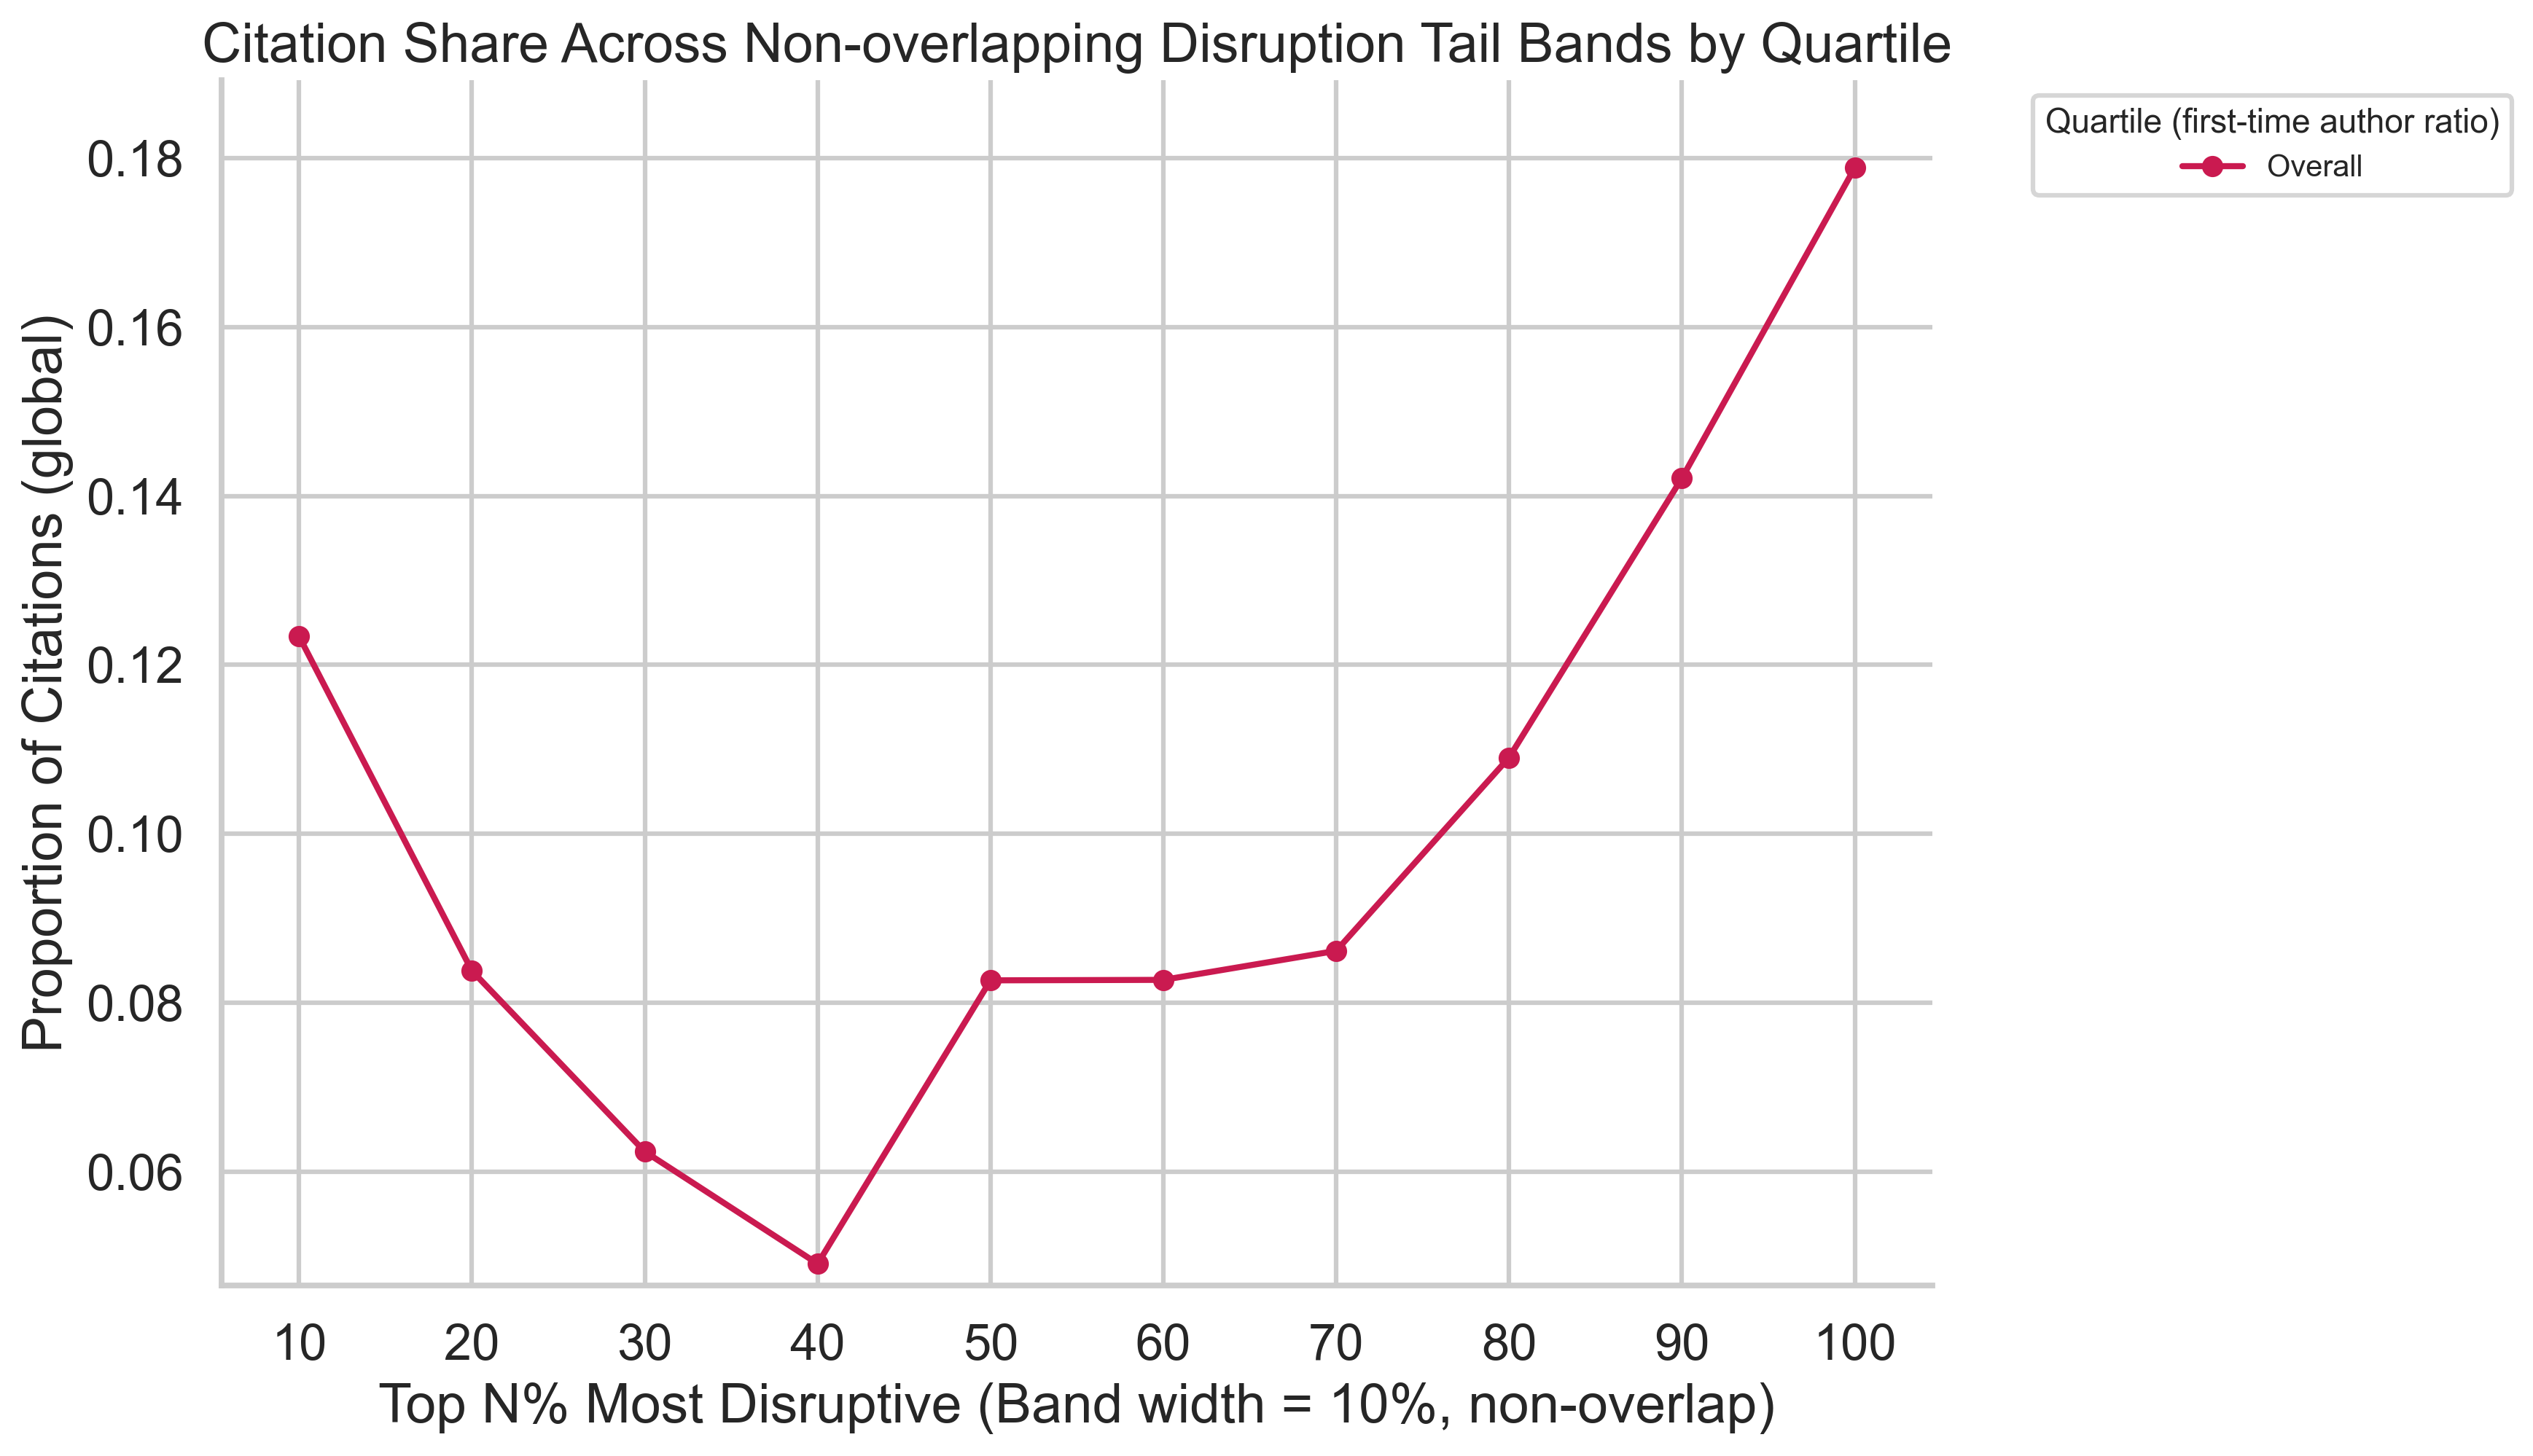

In [42]:
res_quartiles = plot_citation_share_by_disruption_quartiles(
    final_df,
    disruption_col="disruption_percentile",
    citation_col="citation_count",
    band_width=10,  # 20 bands on x-axis
    quartile_column=None,  # your 4-bin labels
    normalize="global",  # or "global"
    fig_dir="Final_Figures",
)